# Rootzone Soft-Sensor V8 - Unified Tuned Early-Day


In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import HuberRegressor
import matplotlib.pyplot as plt

# ==========================================
# 1. Data Loading & Helper Functions
# ==========================================
df = pd.read_csv('master.csv', parse_dates=['timestamp'])
df = df.sort_values('timestamp').set_index('timestamp')
for c in df.columns:
    df[c] = pd.to_numeric(df[c], errors='coerce')
master_df = df.copy().sort_index()

n_ph = int(master_df['ph'].notna().sum()) if 'ph' in master_df.columns else 0
n_ec = int(master_df['ec_ms'].notna().sum()) if 'ec_ms' in master_df.columns else 0
n_both = int((master_df['ph'].notna() & master_df['ec_ms'].notna()).sum()) if {'ph','ec_ms'}.issubset(master_df.columns) else 0

print(f'Loaded: {len(df)} rows')
print(f'Labeled samples -> pH: {n_ph}, EC: {n_ec}, both: {n_both}')

ACID_FERTS = ['Phosphoric acid[mg]-H3PO4']
SALT_FERTS = ['Monopotassium Phosphate[mg] -KH2PO4', 'Potassium Chloride[mg] - KCL',
              'Kortin [mg]', 'Ammonium Nitrate [mg] -NH4NO3', 'Gypsum - CaSO4*2H2O [mg]']
CORE_SALT_FERTS = ['Monopotassium Phosphate[mg] -KH2PO4', 'Potassium Chloride[mg] - KCL',
                   'Ammonium Nitrate [mg] -NH4NO3']
EC_COMPONENT_COLS = {
    'salt_kh2po4': 'Monopotassium Phosphate[mg] -KH2PO4',
    'salt_kcl': 'Potassium Chloride[mg] - KCL',
    'salt_kortin': 'Kortin [mg]',
    'salt_nh4no3': 'Ammonium Nitrate [mg] -NH4NO3',
    'salt_gypsum': 'Gypsum - CaSO4*2H2O [mg]',
}

def _to_num(s, d=0.0): return pd.to_numeric(s, errors='coerce').fillna(d)

def _sum_avail(fr, cols):
    u = [c for c in cols if c in fr.columns]
    return float(fr[u].apply(pd.to_numeric, errors='coerce').fillna(0).sum().sum()) if u else 0.0

def _sum_avail_series(fr, cols):
    u = [c for c in cols if c in fr.columns]
    return fr[u].apply(pd.to_numeric, errors='coerce').fillna(0).sum(axis=1) if u else pd.Series(0.0, index=fr.index)

def _get_fert_any(fr):
    if 'fertilization_flag' in fr.columns: return _to_num(fr['fertilization_flag'])
    a = 'fertilization_type_a_flag' in fr.columns
    b = 'fertilization_type_b_flag' in fr.columns
    if a or b:
        fa = _to_num(fr['fertilization_type_a_flag']) if a else pd.Series(0., index=fr.index)
        fb = _to_num(fr['fertilization_type_b_flag']) if b else pd.Series(0., index=fr.index)
        return ((fa > 0) | (fb > 0)).astype(float)
    return pd.Series(0., index=fr.index)


Loaded: 16682 rows
Labeled samples -> pH: 109, EC: 109, both: 109


In [2]:
# ==========================================
# 2. Feature Extraction
# ==========================================
def get_features_for_row(master_df, anchor_idx, current_idx):
    t0 = pd.Timestamp(anchor_idx)
    t1 = pd.Timestamp(current_idx)
    ph0 = float(master_df.loc[t0, 'ph'])
    ec0 = float(master_df.loc[t0, 'ec_ms'])
    gap_h = float((t1 - t0).total_seconds() / 3600.0)
    safe_gap_h = max(gap_h, 0.16)

    # Strictly use [t0, t1) to avoid peeking at sample-time events
    seg = master_df.loc[(master_df.index >= t0) & (master_df.index < t1)]

    # Absolute sums
    fert_acid_total = _sum_avail(seg, ACID_FERTS)
    fert_salt_total = _sum_avail(seg, SALT_FERTS)
    fert_total = fert_acid_total + fert_salt_total
    irr_total = float(_to_num(seg['irrigation_ml_current']).sum()) if 'irrigation_ml_current' in seg.columns else 0.0

    # Time-weighted sums (recency-aware)
    fert_acid_s = _sum_avail_series(seg, ACID_FERTS)
    fert_salt_s = _sum_avail_series(seg, SALT_FERTS)
    fert_total_s = fert_acid_s + fert_salt_s
    irr_s = _to_num(seg['irrigation_ml_current']) if 'irrigation_ml_current' in seg.columns else pd.Series(0.0, index=seg.index)

    time_to_t1_hours = (t1 - seg.index).total_seconds() / 3600.0 if len(seg) else np.array([])
    decay_lambda = 0.34
    weights = np.exp(-decay_lambda * time_to_t1_hours) if len(seg) else np.array([])

    weighted_irr = float((irr_s * weights).sum()) if len(seg) else 0.0
    weighted_fert_acid = float((fert_acid_s * weights).sum()) if len(seg) else 0.0
    weighted_fert_salt = float((fert_salt_s * weights).sum()) if len(seg) else 0.0
    weighted_total_fert = float((fert_total_s * weights).sum()) if len(seg) else 0.0

    # Core drivers
    # fert_conc: +1 denominator keeps values stable when irr_total==0
    fert_conc = float(fert_total / (irr_total + 1.0))
    # fert_concentration used to divide by (irr_total + 1e-6), producing values
    # up to ~1e6 when irr_total==0 — extreme outliers that dominated tree splits.
    # Unified to the same +1 denominator as fert_conc, clipped as a safety net.
    fert_concentration = float(np.clip(fert_total / (irr_total + 1.0), 0, 1e4))
    salt_balance = float(fert_salt_total - irr_total)

    ET0_sum = float(_to_num(seg['ET0']).sum()) if 'ET0' in seg.columns else 0.0
    ET0_per_hour = float(ET0_sum / safe_gap_h)
    # leaching_fraction: clipped to [0, 100] — short gaps with near-zero ET0
    # produced astronomically large values that dominated tree splits.
    leaching_fraction = float(np.clip(irr_total / (ET0_sum + 1e-3), 0, 100))

    log_ec_drive = float(np.log(fert_conc + 0.01) - np.log(ec0 + 0.01))
    ph_drive = float(fert_total / (ph0 + 1e-3))

    # pH-specific features
    # h3po4_total: direct phosphoric acid dose in window
    H3PO4_COL = 'Phosphoric acid[mg]-H3PO4'
    h3po4_total = float(_to_num(seg[H3PO4_COL]).sum()) if H3PO4_COL in seg.columns else 0.0
    # acid_rate: phosphoric acid applied per hour — separates a large dose
    # over a long gap from a concentrated burst, which matters for pH drop.
    acid_rate = float(fert_acid_total / safe_gap_h)
    # ph_buffer_ratio: acid load relative to ionic strength (ec0). Higher EC
    # means more ions in solution = more buffering = same acid moves pH less.
    ph_buffer_ratio = float(fert_acid_total / (ec0 + 0.1))
    # soil_temp_sq: respiration rate roughly doubles per 10°C (Q10 rule),
    # so a quadratic term captures the nonlinear CO2 production effect on pH.
    soil_temp_sq = float(_to_num(seg['soil_temp_pred']).mean() ** 2) if 'soil_temp_pred' in seg.columns and len(seg) > 0 else 0.0

    # Climate dynamics
    if 'internal_air_temp_c' in seg.columns and 'internal_rh_%' in seg.columns and len(seg) > 0:
        ts = _to_num(seg['internal_air_temp_c'])
        rhs = _to_num(seg['internal_rh_%'])
        ess = 0.6108 * np.exp((17.27 * ts) / (ts + 237.3))
        vpds = ess * (1. - rhs / 100.)
        vpd_mean = float(vpds.mean())
    else:
        vpd_mean = 0.0

    soil_temp_mean = float(_to_num(seg['soil_temp_pred']).mean()) if 'soil_temp_pred' in seg.columns and len(seg) > 0 else 0.0
    canopy = float(_to_num(seg['canopy_cover']).mean()) if 'canopy_cover' in seg.columns and len(seg) > 0 else 0.0
    transpiration_pull = float(vpd_mean * canopy)
    evapo_concentration = float(ET0_sum * canopy)

    temp_s = _to_num(seg['internal_air_temp_c']) if 'internal_air_temp_c' in seg.columns else pd.Series(dtype=float)
    if len(temp_s) > 1:
        temp_trend = float(temp_s.iloc[-1] - temp_s.iloc[0])
        temp_range = float(temp_s.max() - temp_s.min())
    else:
        temp_trend = 0.0
        temp_range = 0.0

    rad_s = _to_num(seg['internal_radiation']) if 'internal_radiation' in seg.columns else pd.Series(dtype=float)
    rad_max = float(rad_s.max()) if len(rad_s) > 0 else 0.0
    daylight_proportion = float((rad_s > 10).sum() / 6.0 / safe_gap_h) if len(rad_s) > 0 else 0.0

    # Interaction features (batch 1) — placed here so vpd_mean, soil_temp_mean,
    # and rad_s are all already defined.
    # rad_integral: cumulative light energy (Wh/m²) — plants integrate radiation
    # over the full window, not just whether it was daytime.
    rad_integral = float(rad_s.sum() * (10.0 / 60.0)) if len(rad_s) > 0 else 0.0
    # ph_deviation: distance from agronomic optimum (6.5) — encodes the
    # operator mean-reversion pressure that ph0 alone cannot capture.
    ph_deviation = float(ph0 - 6.5)
    # photo_temp_interaction: vpd_mean × soil_temp_mean — coupled biochemical
    # CO2 uptake rate; neither driver predicts pH change independently.
    photo_temp_interaction = float(vpd_mean * soil_temp_mean)

    # Hours since events
    if 'irrigation_ml_current' in seg.columns and len(seg) > 0:
        ie = _to_num(seg['irrigation_ml_current'])
        ii = ie[ie > 0].index
        hrs_since_irr = float((t1 - ii.max()).total_seconds() / 3600.) if len(ii) > 0 else gap_h
    else:
        hrs_since_irr = gap_h

    fser = _get_fert_any(seg) if len(seg) > 0 else pd.Series(dtype=float)
    fi2 = fser[fser > 0].index
    hrs_since_fert = float((t1 - fi2.max()).total_seconds() / 3600.) if len(fi2) > 0 else gap_h

    # Interaction features (batch 2) — placed here so hrs_since_irr is defined.
    # acid_dilution: acid / (irr + fert + 1) — actual acid concentration in
    # the liquid applied; neither term alone captures dilution by irrigation.
    acid_dilution = float(fert_acid_total / (irr_total + fert_total + 1.0))
    # buffered_acid_pressure: recency-weighted acid concentration scaled by
    # irrigation dilution and EC buffering.
    buffered_acid_pressure = float(weighted_fert_acid / ((weighted_irr + 1.0) * (ec0 + 0.1)))
    # canopy_et0: canopy × ET0_sum — actual photosynthetic demand met by crop;
    # small canopy at high ET0 has minimal CO2 uptake and pH effect.
    canopy_et0 = float(canopy * ET0_sum)
    # salt_stress_index: hrs_since_irr × ec0 — salt concentration builds up
    # when irrigation is withheld; high EC × long gap = stronger buffering.
    salt_stress_index = float(hrs_since_irr * ec0)

    # Interaction features (batch 3)
    # rad_x_canopy: mean radiation x canopy = actual light intercepted by leaves,
    # the direct driver of photosynthesis and CO2 uptake (r=0.51 with dph).
    rad_x_canopy = float(rad_s.mean() * canopy) if len(rad_s) > 0 else 0.0
    # temp_x_canopy: soil_temp x canopy = root mass x temperature drives root
    # respiration CO2 production which acidifies the rootzone.
    temp_x_canopy = float(soil_temp_mean * canopy)

    # Time-of-day (diurnal cycles)
    hour_a = t0.hour + t0.minute / 60.0
    hour_b = t1.hour + t1.minute / 60.0

    component_totals = {
        key: float(_to_num(seg[col]).sum()) if col in seg.columns else 0.0
        for key, col in EC_COMPONENT_COLS.items()
    }
    salt_conc_t0_t1 = float(fert_salt_total / (irr_total + 1.0))
    acid_conc_t0_t1 = float(fert_acid_total / (irr_total + 1.0))
    weighted_salt_conc = float(weighted_fert_salt / (weighted_irr + 1.0))
    weighted_total_conc = float(weighted_total_fert / (weighted_irr + 1.0))
    salt_per_hour = float(fert_salt_total / safe_gap_h)
    irr_per_hour = float(irr_total / safe_gap_h)
    salt_to_et0 = float(fert_salt_total / (ET0_sum + 0.1))
    irr_to_et0 = float(irr_total / (ET0_sum + 0.1))
    overnight_fraction = float((_to_num(seg['internal_radiation']) <= 10).sum() / 6.0 / safe_gap_h) \
        if len(seg) > 0 and 'internal_radiation' in seg.columns else 0.0
    salt_x_daylight = float(fert_salt_total * daylight_proportion)
    days_after_planting_t0 = float(master_df.loc[t0, 'days_after_planting']) \
        if 'days_after_planting' in master_df.columns else 0.0
    days_after_planting_t1 = float(master_df.loc[t1, 'days_after_planting']) \
        if 'days_after_planting' in master_df.columns else days_after_planting_t0
    canopy_t1 = float(master_df.loc[t1, 'canopy_cover']) if 'canopy_cover' in master_df.columns else canopy
    stage_x_salt_conc = float((days_after_planting_t1 / 100.0) * salt_conc_t0_t1)
    ec_regime_low = float(ec0 <= 0.5)
    ec_regime_mid = float((ec0 > 0.5) and (ec0 <= 1.5))
    ec_regime_high = float((ec0 > 1.5) and (ec0 <= 3.0))
    ec_regime_very_high = float(ec0 > 3.0)
    fertigation_event = float(fert_salt_total > 0)
    low_dilution_event = float(irr_total <= 300.0)
    salt_shock_event = float((fert_salt_total >= 325.0) and (irr_total <= 300.0))
    super_shock_event = float((fert_salt_total >= 900.0) and (irr_total <= 400.0))
    ec_gap_interaction = float(ec0 * gap_h)
    ec_log_anchor = float(np.log(ec0 + 0.05))
    recent_6h = seg.loc[seg.index >= t1 - pd.Timedelta(hours=6)] if len(seg) > 0 else seg
    salt_recent_6h = float(_sum_avail(recent_6h, SALT_FERTS)) if len(recent_6h) > 0 else 0.0
    core_salt_s = _sum_avail_series(seg, CORE_SALT_FERTS) if len(seg) > 0 else pd.Series(0.0, index=seg.index)
    salt_event_idx = core_salt_s[core_salt_s > 0].index.max() if len(core_salt_s[core_salt_s > 0]) else None
    irr_event_idx = irr_s[irr_s > 0].index.max() if len(irr_s[irr_s > 0]) else None
    last_salt_dose = float(core_salt_s.loc[salt_event_idx]) if salt_event_idx is not None else 0.0
    last_irr_amount = float(irr_s.loc[salt_event_idx]) if salt_event_idx is not None and salt_event_idx in irr_s.index else 0.0
    hrs_since_last_salt_event = float((t1 - salt_event_idx).total_seconds() / 3600.0) if salt_event_idx is not None else gap_h
    last_event_salt_conc = float(last_salt_dose / (last_irr_amount + 1.0))
    irr_after_last_salt = float(_to_num(seg.loc[seg.index > salt_event_idx, 'irrigation_ml_current']).sum()) \
        if salt_event_idx is not None and 'irrigation_ml_current' in seg.columns else 0.0

    return {
        'ph0': ph0,
        'ec0': ec0,
        'gap_hours': gap_h,

        # absolute totals
        'irr_total_t0_t1': irr_total,
        'fert_total_t0_t1': fert_total,
        'fert_salt_total_t0_t1': fert_salt_total,
        'salt_balance_t0_t1': salt_balance,
        'ET0_sum_t0_t1': ET0_sum,

        # weighted totals
        'weighted_irr': weighted_irr,
        'weighted_total_fert': weighted_total_fert,
        'weighted_fert_acid': weighted_fert_acid,
        'weighted_fert_salt': weighted_fert_salt,

        # driver terms
        'fert_conc': fert_conc,
        'fert_concentration': fert_concentration,
        'log_ec_drive': log_ec_drive,
        'ph_drive': ph_drive,
        'leaching_fraction': leaching_fraction,
        'ET0_per_hour': ET0_per_hour,

        # pH-specific
        'acid_rate': acid_rate,
        'ph_buffer_ratio': ph_buffer_ratio,
        'soil_temp_sq': soil_temp_sq,

        # interaction features (batch 1)
        'rad_integral': rad_integral,
        'ph_deviation': ph_deviation,
        'photo_temp_interaction': photo_temp_interaction,

        # interaction features (batch 2)
        'acid_dilution': acid_dilution,
        'buffered_acid_pressure': buffered_acid_pressure,
        'canopy_et0': canopy_et0,
        'salt_stress_index': salt_stress_index,

        # interaction features (batch 3)
        'rad_x_canopy': rad_x_canopy,
        'temp_x_canopy': temp_x_canopy,

        # climate
        'vpd_mean': vpd_mean,
        'soil_temp_mean': soil_temp_mean,
        'soil_temp_t0': soil_temp_mean,  # alias: soil temp at anchor point
        'canopy': canopy,
        'transpiration_pull': transpiration_pull,
        'evapo_concentration': evapo_concentration,

        # fertilization chemistry
        'h3po4_total': h3po4_total,
        **component_totals,
        'salt_conc_t0_t1': salt_conc_t0_t1,
        'acid_conc_t0_t1': acid_conc_t0_t1,
        'weighted_salt_conc': weighted_salt_conc,
        'weighted_total_conc': weighted_total_conc,
        'salt_per_hour': salt_per_hour,
        'irr_per_hour': irr_per_hour,
        'salt_to_et0': salt_to_et0,
        'irr_to_et0': irr_to_et0,
        'salt_x_daylight': salt_x_daylight,
        'overnight_fraction': overnight_fraction,
        'days_after_planting_t0': days_after_planting_t0,
        'days_after_planting_t1': days_after_planting_t1,
        'canopy_t1': canopy_t1,
        'stage_x_salt_conc': stage_x_salt_conc,
        'ec_regime_low': ec_regime_low,
        'ec_regime_mid': ec_regime_mid,
        'ec_regime_high': ec_regime_high,
        'ec_regime_very_high': ec_regime_very_high,
        'fertigation_event': fertigation_event,
        'low_dilution_event': low_dilution_event,
        'salt_shock_event': salt_shock_event,
        'super_shock_event': super_shock_event,
        'ec_gap_interaction': ec_gap_interaction,
        'ec_log_anchor': ec_log_anchor,
        # recency / dynamics
        'hrs_since_irr': hrs_since_irr,
        'hrs_since_fert': hrs_since_fert,
        'temp_trend': temp_trend,
        'temp_range': temp_range,
        'rad_max': rad_max,
        'daylight_proportion': daylight_proportion,
        'salt_recent_6h': salt_recent_6h,
        'hrs_since_last_salt_event': hrs_since_last_salt_event,
        'irr_after_last_salt': irr_after_last_salt,
        'last_event_salt_conc': last_event_salt_conc,

        # diurnal
        'hour_sin_a': float(np.sin(2 * np.pi * hour_a / 24)),
        'hour_cos_a': float(np.cos(2 * np.pi * hour_a / 24)),
        'hour_sin_b': float(np.sin(2 * np.pi * hour_b / 24)),
        'hour_cos_b': float(np.cos(2 * np.pi * hour_b / 24)),

        # V6 morning-flag features
        # t0_morning: anchor is a morning reading (pH at daily minimum).
        # r=+0.581 with ΔpH on gap>6h. Targets morning-to-morning 24h failure mode.
        't0_morning': int(5 <= t0.hour <= 10),
        # t1_morning: target is a morning reading (pH at daily minimum).
        # r=−0.557 with ΔpH on gap>6h.
        't1_morning': int(5 <= t1.hour <= 10),
        't1_early_day': int(5 <= (t1.hour + t1.minute / 60.0) < 13.0),

        # soil_delta: soil temperature change t0→t1.
        # r=+0.604 with ΔpH — strongest new feature found.
        # Warming rootzone → rising pH; cooling → falling pH.
        'soil_delta': float(
            (_to_num(master_df.loc[t1:t1, 'soil_temp_pred']).iloc[0]
             if t1 in master_df.index and master_df.loc[t1, 'soil_temp_pred'] != 0
             else float(_to_num(seg['soil_temp_pred']).iloc[-1]) if len(seg) > 0 else 0.0)
            - float(_to_num(master_df.loc[t0:t0, 'soil_temp_pred']).iloc[0])
        ),
        # rad_t1_log: log(1 + radiation at measurement moment t1).
        # Low linear r but strong non-linear pattern — dark/dim/bright splits.
        'rad_t1_log': float(np.log1p(
            float(_to_num(master_df.loc[t1:t1, 'internal_radiation']).iloc[0])
            if t1 in master_df.index else 0.0
        )),
        # overnight_h: hours of darkness in window (radiation ≤ 10 W/m²).
        # CO2 accumulates during dark → pH drops. Captures overnight base shift.
        'overnight_h': float((_to_num(seg['internal_radiation']) <= 10).sum()) / 6.0
            if len(seg) > 0 else 0.0,
        # rad_morning: total radiation 06:00–12:00 within window.
        # Morning photosynthesis intensity → determines afternoon pH peak magnitude.
        'rad_morning': float(_to_num(
            seg.loc[(seg.index.hour >= 6) & (seg.index.hour < 12), 'internal_radiation']
        ).sum()) if len(seg) > 0 else 0.0,
    }


# ==========================================
# 2b. History Feature Extraction (24h before t1 — all anchored to t1)
# ==========================================
def get_history_features(master_df, t0, t1):
    """
    Extract 7 history features — all anchored to t1.

    All windows use t1 as the reference point, looking back up to 24h.
    No leakage: only operational events (irrigation/fertilization) are read,
    never pH or EC at t1.

    Irrigation sub-windows (anchored to t1):
      recent : [t1-6h,  t1)    — immediate dilution effect
      mid    : [t1-12h, t1-6h) — nitrification peak (8-16h lag)
      prior  : [t1-24h, t1-12h) — residual buffering / background

    Acid fertilization:
      hist_acid_decay — exponentially decayed sum over [t1-24h, t1)
      decay from t1: dose * exp(-λ * hrs_before_t1), λ=0.34/hr
      encodes both amount and recency in one feature.

    State features (anchored to t1, window [t1-24h, t1)):
      hist_salt_buildup   — net salt accumulation in the 24h before t1
      hist_hrs_since_fert — hours since last fertigation before t1
      hist_hrs_since_irr  — hours since last irrigation before t1
    """
    t0 = pd.Timestamp(t0)
    t1 = pd.Timestamp(t1)

    w_prior_start = t1 - pd.Timedelta(hours=24)

    def _get_seg(start, stop):
        """Rows in [start, stop)."""
        if start >= stop:
            return master_df.iloc[0:0]
        return master_df.loc[(master_df.index >= start) & (master_df.index < stop)]

    # ── Irrigation sub-windows: full [t1-Xh, t1) including t0→t1 ────────────
    seg_irr_recent = _get_seg(t1 - pd.Timedelta(hours=6),  t1)
    seg_irr_mid    = _get_seg(t1 - pd.Timedelta(hours=12), t1 - pd.Timedelta(hours=6))
    seg_irr_prior  = _get_seg(t1 - pd.Timedelta(hours=24), t1 - pd.Timedelta(hours=12))

    def _irr(seg):
        if 'irrigation_ml_current' not in seg.columns or len(seg) == 0:
            return 0.0
        return float(_to_num(seg['irrigation_ml_current']).sum())

    irr_recent = _irr(seg_irr_recent)
    irr_mid    = _irr(seg_irr_mid)
    irr_prior  = _irr(seg_irr_prior)
    hist_dark_recent_6h = (
        float((_to_num(seg_irr_recent['internal_radiation']) <= 10).sum()) / 6.0
        if 'internal_radiation' in seg_irr_recent.columns and len(seg_irr_recent) > 0
        else 0.0
    )

    # ── Salt ramp: full [t1-24h, t1) anchored to t1 ──────────────────────────
    # hist_salt_ramp = sum(dose_i * (1 - exp(-λ * hrs_before_t1)))
    # Salts accumulate and equilibrate — opposite of acid decay.
    # Recent dose (1h ago) gets low weight (not dissolved yet).
    # Old dose (20h ago) gets weight ~1.0 (fully equilibrated).
    seg_salt_full = _get_seg(w_prior_start, t1)
    DECAY_LAMBDA  = 0.34
    hist_salt_ramp = 0.0
    if len(seg_salt_full) > 0:
        salt_doses = _sum_avail_series(seg_salt_full, SALT_FERTS)
        nonzero_salt = salt_doses > 0
        if nonzero_salt.any():
            hrs_s = np.array((t1 - seg_salt_full.index[nonzero_salt]).total_seconds()) / 3600.0
            hist_salt_ramp = float((salt_doses[nonzero_salt].values *
                                    (1.0 - np.exp(-DECAY_LAMBDA * hrs_s))).sum())

    # ── Acid decay: full [t1-24h, t1) anchored to t1 ─────────────────────────
    # hist_acid_decay = sum(dose_i * exp(-λ * hrs_before_t1))
    # Events near t1 get high weight; events 24h before t1 get low weight.
    # λ=0.34/hr matches V3 recency decay constant.
    # Vectorized — avoids O(n²) slowdown during walk-forward retraining.
    seg_acid_full = _get_seg(w_prior_start, t1)
    DECAY_LAMBDA  = 0.34
    if len(seg_acid_full) > 0:
        acid_doses = _sum_avail_series(seg_acid_full, ACID_FERTS)
        nonzero_mask = acid_doses > 0
        if nonzero_mask.any():
            hrs_before_t1 = np.array((t1 - seg_acid_full.index[nonzero_mask]).total_seconds()) / 3600.0
            hist_acid_decay = float((acid_doses[nonzero_mask].values *
                                     np.exp(-DECAY_LAMBDA * hrs_before_t1)).sum())
        else:
            hist_acid_decay = 0.0
    else:
        hist_acid_decay = 0.0

    # ── State features: full 24h before t1, anchored to t1 ───────────────────
    seg_state = _get_seg(t1 - pd.Timedelta(hours=24), t1)

    if len(seg_state) > 1:
        hirr_s     = _to_num(seg_state['irrigation_ml_current']) if 'irrigation_ml_current' in seg_state.columns else pd.Series(0.0, index=seg_state.index)
        irr_s_sum  = float(hirr_s.sum())
        h_salt     = _sum_avail(seg_state, SALT_FERTS)
        hist24_salt_total = float(h_salt)
        # Exponentially decayed salt buildup (λ=0.15/hr, slower than acid):
        # weights recent salt events more than older ones — old Aug 17-18
        # fert events no longer dominate after 2 days of plain irrigation.
        _salt_s = _sum_avail_series(seg_state, SALT_FERTS)
        _nz_salt = _salt_s > 0
        if _nz_salt.any():
            _hrs_before_t1 = np.array((t1 - seg_state.index[_nz_salt]).total_seconds()) / 3600.0
            _decay = np.exp(-0.15 * _hrs_before_t1)
            _decayed_salt = float((_salt_s[_nz_salt].values * _decay).sum())
        else:
            _decayed_salt = 0.0
        hist_salt_buildup = float(_decayed_salt - irr_s_sum * 0.1)

        hfert      = _get_fert_any(seg_state)
        fert_times = seg_state.index[hfert > 0]
        hist_hrs_since_fert = float((t1 - fert_times[-1]).total_seconds() / 3600.) if len(fert_times) > 0 else 24.0

        hirr_times = seg_state.index[hirr_s > 0]
        hist_hrs_since_irr = float((t1 - hirr_times[-1]).total_seconds() / 3600.) if len(hirr_times) > 0 else 24.0
    else:
        hist24_salt_total   = 0.0
        hist_salt_buildup   = 0.0
        hist_hrs_since_fert = 24.0
        hist_hrs_since_irr  = 24.0

    return {
        # irrigation sub-windows anchored to t1 (full window including t0→t1)
        'hist_irr_recent':     irr_recent,
        'hist_irr_mid':        irr_mid,
        'hist_irr_prior':      irr_prior,
        'hist_dark_recent_6h': hist_dark_recent_6h,
        # salt ramp anchored to t1 (equilibration weighting, λ=0.34/hr)
        'hist_salt_ramp':      hist_salt_ramp,
        # acid decay anchored to t1 (amount × recency, λ=0.34/hr)
        'hist_acid_decay':     hist_acid_decay,
        # state features anchored to t0 (24h before window start)
        'hist24_salt_total':   hist24_salt_total,
        'hist_salt_buildup':   hist_salt_buildup,
        'hist_hrs_since_fert': hist_hrs_since_fert,
        'hist_hrs_since_irr':  hist_hrs_since_irr,
    }



def get_target_prevday_features(master_df, t1):
    """Operational carry-over from the previous day before t1.

    These features capture lingering irrigation and acid effects from
    the 24-48h period before the target time without leaking target chemistry.
    """
    t1 = pd.Timestamp(t1)
    start = t1 - pd.Timedelta(hours=48)
    stop = t1 - pd.Timedelta(hours=24)
    seg = master_df.loc[(master_df.index >= start) & (master_df.index < stop)]

    hist48_irr_prevday = (
        float(_to_num(seg['irrigation_ml_current']).sum())
        if 'irrigation_ml_current' in seg.columns and len(seg) > 0
        else 0.0
    )
    hist48_acid_prevday = float(_sum_avail(seg, ACID_FERTS)) if len(seg) > 0 else 0.0
    hist48_salt_prevday = float(_sum_avail(seg, SALT_FERTS)) if len(seg) > 0 else 0.0
    return {
        'hist48_irr_prevday': hist48_irr_prevday,
        'hist48_acid_prevday': hist48_acid_prevday,
        'hist48_salt_prevday': hist48_salt_prevday,
    }

JOINT_SENSOR_IDX = list(master_df.index[master_df['ph'].notna() & master_df['ec_ms'].notna()])
JOINT_SENSOR_POS = {ts: i for i, ts in enumerate(JOINT_SENSOR_IDX)}


def get_features_v6(master_df, anchor_idx, current_idx):
    """Combine window features + t1 history + previous-day target context."""
    window = get_features_for_row(master_df, anchor_idx, current_idx)
    history = get_history_features(master_df, t0=anchor_idx, t1=current_idx)
    prevday = get_target_prevday_features(master_df, t1=current_idx)
    feats = {**window, **history, **prevday}

    t0 = pd.Timestamp(anchor_idx)
    t1 = pd.Timestamp(current_idx)
    recent_2h = master_df.loc[(master_df.index >= t1 - pd.Timedelta(hours=2)) & (master_df.index < t1)]
    hist24 = master_df.loc[(master_df.index >= t0 - pd.Timedelta(hours=24)) & (master_df.index < t0)]
    hist48 = master_df.loc[(master_df.index >= t0 - pd.Timedelta(hours=48)) & (master_df.index < t0)]

    salt_2h = float(_sum_avail(recent_2h, SALT_FERTS)) if len(recent_2h) > 0 else 0.0
    irr_2h = float(_to_num(recent_2h['irrigation_ml_current']).sum()) if 'irrigation_ml_current' in recent_2h.columns and len(recent_2h) > 0 else 0.0
    salt24 = float(_sum_avail(hist24, SALT_FERTS)) if len(hist24) > 0 else 0.0
    irr24 = float(_to_num(hist24['irrigation_ml_current']).sum()) if 'irrigation_ml_current' in hist24.columns and len(hist24) > 0 else 0.0
    salt48 = float(_sum_avail(hist48, SALT_FERTS)) if len(hist48) > 0 else 0.0
    irr48 = float(_to_num(hist48['irrigation_ml_current']).sum()) if 'irrigation_ml_current' in hist48.columns and len(hist48) > 0 else 0.0

    hist_t1_24 = master_df.loc[(master_df.index >= t1 - pd.Timedelta(hours=24)) & (master_df.index < t1)]
    hist_core_t1 = _sum_avail_series(hist_t1_24, CORE_SALT_FERTS) if len(hist_t1_24) > 0 else pd.Series(dtype=float)
    hist_irr_t1 = _to_num(hist_t1_24['irrigation_ml_current']) if 'irrigation_ml_current' in hist_t1_24.columns else pd.Series(0.0, index=hist_t1_24.index)
    nz_hist_core = hist_core_t1[hist_core_t1 > 0]
    if len(nz_hist_core) > 0:
        major_idx = nz_hist_core.index.max()
        major_dose = float(hist_core_t1.loc[major_idx])
        major_irr = float(hist_irr_t1.loc[major_idx]) if major_idx in hist_irr_t1.index else 0.0
        after_major = hist_t1_24.loc[hist_t1_24.index >= major_idx]
        rad_after_major = float(_to_num(after_major['internal_radiation']).sum()) if 'internal_radiation' in after_major.columns else 0.0
        et0_after_major = float(_to_num(after_major['ET0']).sum()) if 'ET0' in after_major.columns else 0.0
        hist_major_last_event_salt_conc_t1 = float(major_dose / (major_irr + 1.0))
        hist_hrs_since_major_salt_t1 = float((t1 - major_idx).total_seconds() / 3600.0)
        hist_plain_after_major_salt_t1 = float(hist_irr_t1.loc[hist_irr_t1.index > major_idx].sum())
        hist_major_salt_light_balance = float(
            hist_major_last_event_salt_conc_t1 * np.log1p(rad_after_major) / (hist_plain_after_major_salt_t1 + 1.0)
        )
        salt_concentration_pressure_t1 = float(
            hist_major_last_event_salt_conc_t1 * et0_after_major / (hist_plain_after_major_salt_t1 + 1.0)
        )
    else:
        hist_major_last_event_salt_conc_t1 = 0.0
        hist_hrs_since_major_salt_t1 = 24.0
        hist_plain_after_major_salt_t1 = 0.0
        hist_major_salt_light_balance = 0.0
        salt_concentration_pressure_t1 = 0.0

    pos = JOINT_SENSOR_POS.get(t0)
    prev_ec_delta = 0.0
    prev_ec_slope = 0.0
    prev_gap_h = feats['gap_hours']
    ec_trend_48h = 0.0
    if pos is not None and pos >= 1:
        t_prev = pd.Timestamp(JOINT_SENSOR_IDX[pos - 1])
        prev_ec = float(master_df.loc[t_prev, 'ec_ms'])
        prev_gap_h = max((t0 - t_prev).total_seconds() / 3600.0, 1e-6)
        prev_ec_delta = float(feats['ec0'] - prev_ec)
        prev_ec_slope = float(prev_ec_delta / prev_gap_h)
        # ec_trend_48h: slope over the last 2 labeled intervals (t_prev2 → t0).
        # Captures sustained EC decline that single-step prev_ec_slope misses.
        # e.g. after a fert peak, 2+ consecutive plain-irrigation drops.
        if pos >= 2:
            t_prev2 = pd.Timestamp(JOINT_SENSOR_IDX[pos - 2])
            ec_prev2 = float(master_df.loc[t_prev2, 'ec_ms'])
            gap_2step = max((t0 - t_prev2).total_seconds() / 3600.0, 1e-6)
            ec_trend_48h = float((feats['ec0'] - ec_prev2) / gap_2step)
        else:
            ec_trend_48h = prev_ec_slope

    gap_h_safe = max(float(feats['gap_hours']), 0.25)
    feats.update({
        'recent_salt_conc_2h': float(salt_2h / (irr_2h + 1.0)),
        'hist24_net_salt': float(salt24 - 0.25 * irr24),
        'hist48_net_salt': float(salt48 - 0.18 * irr48),
        'prev_ec_delta': prev_ec_delta,
        'prev_ec_slope': prev_ec_slope,
        'prev_gap_h': prev_gap_h,
        # ec_trend_48h: 2-step EC momentum — negative = sustained EC decline.
        'ec_trend_48h': ec_trend_48h,
        # washout_flag: 1 when a long gap has heavy plain irrigation and zero
        # salt — the 'post-fert washout' regime where EC drops rapidly.
        # Fires only for gaps ≥8h with >800ml irrigation and no fertigation.
        'washout_flag': float(
            feats['gap_hours'] >= 8.0
            and feats['fert_salt_total_t0_t1'] == 0.0
            and feats['irr_total_t0_t1'] > 800.0
        ),
        'salt_recency_pressure': float(
            feats['last_event_salt_conc'] * np.exp(-feats['hrs_since_last_salt_event'] / 6.0)
        ),
        'hist_major_last_event_salt_conc_t1': hist_major_last_event_salt_conc_t1,
        'hist_hrs_since_major_salt_t1': hist_hrs_since_major_salt_t1,
        'hist_plain_after_major_salt_t1': hist_plain_after_major_salt_t1,
        'hist_major_salt_light_balance': hist_major_salt_light_balance,
        'salt_concentration_pressure_t1': salt_concentration_pressure_t1,
        'timing_balance': float((feats['hrs_since_irr'] - feats['hrs_since_last_salt_event']) / gap_h_safe),
        'salt_event_pos': float(np.clip(1.0 - (feats['hrs_since_last_salt_event'] / gap_h_safe), 0.0, 1.0)),
        # EC balance refresh: current EC interacting with the previous 48h salt load.
        # This is deployable when up to 48h of pre-t0 fertigation history is available.
        'ec0_x_p48_salt': float(feats['ec0'] * salt48),
    })
    return feats


In [3]:
# ==========================================
# 3. Feature Lists + Hyperparameters (V8, EC dynamics refresh)
# ==========================================

HIST_FEATS = [
    'hist_irr_recent',
    'hist_irr_mid',
    'hist_irr_prior',
    'hist_acid_decay',
    'hist_salt_buildup',
    'hist_hrs_since_fert',
    'hist_hrs_since_irr',
]

HIST_FEATS_NO_ACID_DECAY = [
    'hist_irr_recent',
    'hist_irr_mid',
    'hist_irr_prior',
    'hist_salt_buildup',
    'hist_hrs_since_fert',
    'hist_hrs_since_irr',
]

feature_cols_ph_baseline = [
    'ph0', 'ec0',
    'gap_hours',
    'ET0_per_hour',
    'transpiration_pull',
    'photo_temp_interaction',
    'temp_x_canopy',
    't0_morning',
    't1_morning',
    'soil_delta',
    'rad_t1_log',
    'overnight_h',
    'rad_morning',
    *HIST_FEATS,
    'hist48_irr_prevday',
    'hist48_acid_prevday',
]

feature_cols_ph_balanced = [
    'ph0', 'ec0',
    'gap_hours',
    'ET0_per_hour',
    'transpiration_pull',
    'photo_temp_interaction',
    'temp_x_canopy',
    't0_morning',
    't1_morning',
    'soil_delta',
    'rad_t1_log',
    'hist_dark_recent_6h',
    'rad_morning',
    *HIST_FEATS_NO_ACID_DECAY,
    'hist48_irr_prevday',
    'hist48_acid_prevday',
    'h3po4_total',
]

# Walk-forward verified:
# baseline features reserved_all -> walk MAE 0.3212, walk R2 0.9323
# balanced features original params -> walk MAE 0.2941, walk R2 0.9357
# balanced features tuned params -> walk MAE 0.2852, walk R2 0.9373
# Holdout is secondary here; keep the walk-forward feature set active.
feature_cols_ph = feature_cols_ph_balanced

# EC feature set: global single-model winner from the focused timing search.
# Keeps the strong anchor/current forcing terms, then adds delayed major-salt state
# only where it improved walk-forward error without using a second specialist model.
# EC feature set: clean deployable 25-feature EC balance model.
# Replaces the older `rad_morning` and `salt_concentration_pressure_t1`
# terms with `ec0_x_p48_salt`, which uses only the previous 48h before t0.
feature_cols_ec = [
    'stage_x_salt_conc',
    'log_ec_drive',
    'soil_temp_mean',
    'ec_log_anchor',
    'salt_conc_t0_t1',
    'ec0',
    'irr_to_et0',
    'temp_trend',
    'prev_ec_slope',
    'irr_total_t0_t1',
    'rad_t1_log',
    'hour_cos_b',
    'hour_sin_b',
    'salt_recency_pressure',
    'last_event_salt_conc',
    'hrs_since_irr',
    'hrs_since_fert',
    'hrs_since_last_salt_event',
    'irr_after_last_salt',
    'recent_salt_conc_2h',
    'hist_hrs_since_fert',
    'hist_major_last_event_salt_conc_t1',
    'timing_balance',
    'salt_event_pos',
    'ec0_x_p48_salt',
]

feature_cols_ph_specialist = [
    'ph0',
    'ec0',
    'gap_hours',
    'h3po4_total',
    'acid_conc_t0_t1',
    'weighted_fert_acid',
    'hist_acid_decay',
    'hist48_acid_prevday',
    'fert_salt_total_t0_t1',
    'salt_conc_t0_t1',
    'last_event_salt_conc',
    'recent_salt_conc_2h',
    'hrs_since_last_salt_event',
    'irr_after_last_salt',
    'irr_total_t0_t1',
    'irr_to_et0',
    'ET0_sum_t0_t1',
    'soil_temp_mean',
    'rad_t1_log',
    'hist_dark_recent_6h',
    'hour_cos_b',
    'hist_major_last_event_salt_conc_t1',
    'timing_balance',
    'ec0_x_p48_salt',
    'fertigation_event',
    'low_dilution_event',
]
feature_cols_ec_specialist = [
    'ec0',
    'ec_log_anchor',
    'gap_hours',
    'fert_salt_total_t0_t1',
    'salt_conc_t0_t1',
    'last_event_salt_conc',
    'recent_salt_conc_2h',
    'hrs_since_last_salt_event',
    'irr_after_last_salt',
    'irr_total_t0_t1',
    'irr_to_et0',
    'ET0_sum_t0_t1',
    'soil_temp_mean',
    'temp_trend',
    'rad_t1_log',
    'hour_sin_b',
    'hour_cos_b',
    'hist_major_last_event_salt_conc_t1',
    'hist_hrs_since_fert',
    'salt_event_pos',
    'timing_balance',
    'prev_ec_slope',
    'ec0_x_p48_salt',
    'super_shock_event',
    'low_dilution_event',
    'fertigation_event',
]

best_ph_params = {
    'n_estimators': 650,
    'learning_rate': 0.07,
    'max_depth': 4,
    'min_child_weight': 3,
    'subsample': 0.6,
    'colsample_bytree': 0.5,
    'reg_alpha': 3.0,
    'reg_lambda': 1.0,
    'random_state': 42,
    'n_jobs': -1,
    'tree_method': 'hist'
}

best_ec_params = {
    'n_estimators': 450,
    'learning_rate': 0.03,
    'max_depth': 4,
    'min_child_weight': 1,
    'subsample': 0.72,
    'colsample_bytree': 0.75,
    'reg_alpha': 1.0,
    'reg_lambda': 2.0,
    'random_state': 42,
    'n_jobs': -1,
    'tree_method': 'hist',
    'objective': 'reg:pseudohubererror',
    'huber_slope': 2.0,
}


print(f"pH features active: {len(feature_cols_ph)}")
print(f"pH features baseline: {len(feature_cols_ph_baseline)}")
print(f"EC features: {len(feature_cols_ec)} base + {len(feature_cols_ec_specialist)} specialist")
print(f"pH specialist features: {len(feature_cols_ph_specialist)}")


pH features active: 22
pH features baseline: 22
EC features: 25 base + 26 specialist
pH specialist features: 26


In [4]:
# ==========================================
# 4. Holdout Schedule + Target-Specific Walk-Forward
# ==========================================
EVAL_WINDOW_H = 26.0
DEFAULT_HOLDOUT_START_POS = 61
DEFAULT_HOLDOUT_ANCHOR_PATTERN = (1,)
EXPLICIT_HOLDOUT_ANCHORS = [6, 18, 22, 25, 32, 38, 44, 51, 59, 61, 65, 70, 76, 82, 91, 98, 102]
HOLDOUT_SKIP_KEEP_IDX_BY_ANCHOR = {
    102: (0, 2, 3, 4),
}
HOLDOUT_SKIP_SLICE_BY_ANCHOR = {}
SKIP_MAX_GAP_H = 26.0
EC_TARGET_SHIFT = 0.005


def select_anchor_skip_targets(anchor_pos, skip_targets, keep_idx_by_anchor=None, skip_slice_by_anchor=None):
    if keep_idx_by_anchor and anchor_pos in keep_idx_by_anchor:
        keep_idx = tuple(int(i) for i in keep_idx_by_anchor[anchor_pos])
        return [skip_targets[i] for i in keep_idx if 0 <= i < len(skip_targets)]
    if not skip_slice_by_anchor:
        return skip_targets
    skip_slice = skip_slice_by_anchor.get(anchor_pos)
    if skip_slice is None:
        return skip_targets
    start, stop = skip_slice
    return skip_targets[start:stop]


def build_skip_holdout_schedule(sensor_idx, start_pos=0,
                                horizon_hours=24.0,
                                anchor_step_pattern=(0,),
                                explicit_anchor_positions=None,
                                keep_idx_by_anchor=None,
                                skip_slice_by_anchor=None):
    pattern = tuple(anchor_step_pattern)
    if explicit_anchor_positions:
        anchors = []
        holdout_pairs = []
        N = len(sensor_idx)
        positions = sorted(set(
            [int(pos) for pos in explicit_anchor_positions if 0 <= int(pos) < N - 1]
        ))
        for pos in positions:
            t0 = sensor_idx[pos]
            window_targets = []
            for k in range(pos + 1, N):
                gap_h = (sensor_idx[k] - t0).total_seconds() / 3600.0
                if gap_h > horizon_hours:
                    break
                window_targets.append((k, gap_h))

            if not window_targets:
                continue

            window_end_pos = window_targets[-1][0]
            skip_targets = [(k, gap_h) for k, gap_h in window_targets if k >= pos + 2]
            skip_targets = select_anchor_skip_targets(pos, skip_targets, keep_idx_by_anchor, skip_slice_by_anchor)
            if not skip_targets:
                continue

            anchors.append(dict(
                anchor_pos=pos,
                anchor_time=t0,
                window_end_pos=window_end_pos,
                window_end_time=sensor_idx[window_end_pos],
                n_skip_targets=len(skip_targets),
            ))
            holdout_pairs.extend((pos, k, gap_h) for k, gap_h in skip_targets)
        return anchors, holdout_pairs

    if not pattern:
        raise ValueError('anchor_step_pattern must not be empty')

    anchors = []
    holdout_pairs = []
    pos = start_pos
    pattern_idx = 0
    N = len(sensor_idx)

    while pos < N - 2:
        t0 = sensor_idx[pos]
        window_targets = []
        for k in range(pos + 1, N):
            gap_h = (sensor_idx[k] - t0).total_seconds() / 3600.0
            if gap_h > horizon_hours:
                break
            window_targets.append((k, gap_h))

        if not window_targets:
            pos += 1
            continue

        window_end_pos = window_targets[-1][0]
        skip_targets = [(k, gap_h) for k, gap_h in window_targets if k >= pos + 2]
        skip_targets = select_anchor_skip_targets(pos, skip_targets, keep_idx_by_anchor, skip_slice_by_anchor)

        if skip_targets:
            anchors.append(dict(
                anchor_pos=pos,
                anchor_time=t0,
                window_end_pos=window_end_pos,
                window_end_time=sensor_idx[window_end_pos],
                n_skip_targets=len(skip_targets),
            ))
            holdout_pairs.extend((pos, k, gap_h) for k, gap_h in skip_targets)
            step = pattern[pattern_idx % len(pattern)]
            pattern_idx += 1
            next_pos = window_end_pos + step
        else:
            next_pos = pos + 1

        if next_pos <= pos:
            next_pos = pos + 1
        pos = next_pos

    return anchors, holdout_pairs


_sensor_idx_all = list(master_df.index[master_df['ph'].notna() & master_df['ec_ms'].notna()])
HOLDOUT_ANCHORS, HOLDOUT_SKIP_PAIRS_WITH_GAP = build_skip_holdout_schedule(
    _sensor_idx_all,
    start_pos=DEFAULT_HOLDOUT_START_POS,
    horizon_hours=EVAL_WINDOW_H,
    anchor_step_pattern=DEFAULT_HOLDOUT_ANCHOR_PATTERN,
    explicit_anchor_positions=EXPLICIT_HOLDOUT_ANCHORS,
    keep_idx_by_anchor=HOLDOUT_SKIP_KEEP_IDX_BY_ANCHOR,
    skip_slice_by_anchor=HOLDOUT_SKIP_SLICE_BY_ANCHOR,
)
HOLDOUT_SKIP_PAIRS = {(j, k) for j, k, _ in HOLDOUT_SKIP_PAIRS_WITH_GAP}

print(f'Holdout anchors: {len(HOLDOUT_ANCHORS)}')
print(f'Holdout skip pairs: {len(HOLDOUT_SKIP_PAIRS_WITH_GAP)}')
print(
    f'Holdout config -> explicit anchors={EXPLICIT_HOLDOUT_ANCHORS}, '
    f'horizon={EVAL_WINDOW_H}h, skip_cap={SKIP_MAX_GAP_H}h, '
    f'keep_idx={HOLDOUT_SKIP_KEEP_IDX_BY_ANCHOR}, skip_slices={HOLDOUT_SKIP_SLICE_BY_ANCHOR}'
)
if HOLDOUT_ANCHORS:
    preview = ', '.join(f"{a['anchor_time']:%Y-%m-%d %H:%M}" for a in HOLDOUT_ANCHORS[:5])
    print(f'Anchor preview: {preview}')


PH_TRAIN_SKIP_MAX_GAP_H = 26.0
PH_MAX_SKIP_ROWS_PER_TARGET = None
PH_USE_HOLDOUT_SKIP_RESERVATION = True

EC_TRAIN_SKIP_MAX_GAP_H = 26.0
EC_MAX_SKIP_ROWS_PER_TARGET = 4
EC_USE_HOLDOUT_SKIP_RESERVATION = True

print(
    f'pH skip policy -> train_cap={PH_TRAIN_SKIP_MAX_GAP_H}h, '
    f'max_skip_rows={PH_MAX_SKIP_ROWS_PER_TARGET}, '
    f'reserve_holdout={PH_USE_HOLDOUT_SKIP_RESERVATION}'
)
print(
    f'EC skip policy -> train_cap={EC_TRAIN_SKIP_MAX_GAP_H}h, '
    f'max_skip_rows={EC_MAX_SKIP_ROWS_PER_TARGET}, '
    f'reserve_holdout={EC_USE_HOLDOUT_SKIP_RESERVATION}, '
    f'target=log((ec_t1+{EC_TARGET_SHIFT})/(ec0+{EC_TARGET_SHIFT}))'
)


def _skip_policy(target):
    if target == 'ph':
        return {
            'max_gap_hours': PH_TRAIN_SKIP_MAX_GAP_H,
            'max_skip_rows': PH_MAX_SKIP_ROWS_PER_TARGET,
            'reserve_holdout': PH_USE_HOLDOUT_SKIP_RESERVATION,
        }
    return {
        'max_gap_hours': EC_TRAIN_SKIP_MAX_GAP_H,
        'max_skip_rows': EC_MAX_SKIP_ROWS_PER_TARGET,
        'reserve_holdout': EC_USE_HOLDOUT_SKIP_RESERVATION,
    }


def _training_holdout_pairs(target):
    policy = _skip_policy(target)
    return HOLDOUT_SKIP_PAIRS if policy['reserve_holdout'] else set()


def _selected_skip_pairs(sensor_idx, k, target, max_gap_hours=None, holdout_pairs=None, max_skip_rows=None):
    policy = _skip_policy(target)
    active_holdout_pairs = _training_holdout_pairs(target) if holdout_pairs is None else holdout_pairs
    gap_cap = policy['max_gap_hours'] if max_gap_hours is None else max_gap_hours
    row_cap = policy['max_skip_rows'] if max_skip_rows is None else max_skip_rows

    selected = []
    if row_cap == 0:
        return selected

    for back in range(2, k + 1):
        j = k - back
        gap_h = (pd.Timestamp(sensor_idx[k]) - pd.Timestamp(sensor_idx[j])).total_seconds() / 3600.0
        if gap_h > gap_cap:
            break
        if (j, k) in active_holdout_pairs:
            continue
        selected.append((j, k, back, gap_h))
        if row_cap is not None and len(selected) >= row_cap:
            break
    return selected


def _build_skip_rows(master_df, sensor_idx, up_to_pos, target,
                     max_gap_hours=None, holdout_pairs=None, max_skip_rows=None):
    active_holdout_pairs = _training_holdout_pairs(target) if holdout_pairs is None else holdout_pairs
    skip_rows = []
    for k in range(1, up_to_pos + 1):
        t1 = pd.Timestamp(sensor_idx[k])
        for j, _, back, _ in _selected_skip_pairs(
            sensor_idx, k, target,
            max_gap_hours=max_gap_hours,
            holdout_pairs=active_holdout_pairs,
            max_skip_rows=max_skip_rows,
        ):
            f = get_features_v6(master_df, sensor_idx[j], sensor_idx[k])
            f['ph_true'] = float(master_df.loc[t1, 'ph'])
            f['ec_true'] = float(master_df.loc[t1, 'ec_ms'])
            f['timestamp'] = t1 + pd.Timedelta(microseconds=back)
            skip_rows.append(f)
    return skip_rows


def base_ec_weights(tdf):
    y = np.log((tdf['ec_true'].to_numpy() + EC_TARGET_SHIFT) / (tdf['ec0'].to_numpy() + EC_TARGET_SHIFT))
    ec_true = tdf['ec_true'].to_numpy()
    shock = tdf['salt_shock_event'].to_numpy() if 'salt_shock_event' in tdf.columns else np.zeros(len(tdf))
    y_abs = np.abs(y)
    return (
        1.0
        + 0.75 * (ec_true > 0.5)
        + 1.0 * (ec_true > 1.5)
        + 1.5 * (ec_true > 3.0)
        + 1.0 * (y_abs > 0.35)
        + 1.25 * shock
    )


# Unified regime-aware hybrid setup:
# For both pH and EC, XGBoost models the general response and a robust Huber
# specialist models concentrated fertigation-shock intervals. The architecture
# is shared; blend strength differs because pH and EC have different scales.
# Unified hybrid architecture for both targets:
# base XGBoost on every interval + Huber specialist on chemistry-sensitive intervals.
# The prediction gate is shared; each target trains the specialist on its relevant chemistry history.
PH_SPECIALIST_BLEND = 0.25
EC_SPECIALIST_BLEND = 0.85
SPECIALIST_MIN_ROWS = 8
SPECIALIST_GATE_SALT_CONC_MIN = 2.50
SPECIALIST_GATE_EC0_MAX = 0.80
SPECIALIST_GATE_GAP_HOURS_MAX = 10.0


def _is_shock_specialist_case(feats):
    return bool(
        feats.get('fert_salt_total_t0_t1', 0.0) >= 250.0
        and feats.get('irr_after_last_salt', 0.0) <= 1.0
        and feats.get('salt_conc_t0_t1', 0.0) >= SPECIALIST_GATE_SALT_CONC_MIN
        and feats.get('ec0', np.inf) <= SPECIALIST_GATE_EC0_MAX
        and feats.get('gap_hours', np.inf) <= SPECIALIST_GATE_GAP_HOURS_MAX
    )


def _shock_specialist_training_mask(tdf, target):
    if target == 'ph':
        return (
            (tdf['h3po4_total'] > 0.0)
            | (tdf['hist_acid_decay'] > 0.002)
        )
    return (
        (tdf['fert_salt_total_t0_t1'] >= 250.0)
        & (tdf['irr_after_last_salt'] <= 1.0)
    )


def _specialist_X(rows, target):
    cols = feature_cols_ph_specialist if target == 'ph' else feature_cols_ec_specialist
    return rows[cols].replace([np.inf, -np.inf], np.nan).fillna(0.0)


def _fit_huber_specialist(tdf, y, target):
    specialist_mask = _shock_specialist_training_mask(tdf, target)
    if int(specialist_mask.sum()) < SPECIALIST_MIN_ROWS:
        return None
    specialist_model = make_pipeline(
        StandardScaler(),
        HuberRegressor(alpha=0.001, epsilon=1.35, max_iter=5000, tol=1e-05),
    )
    specialist_model.fit(_specialist_X(tdf.loc[specialist_mask], target), y[specialist_mask.to_numpy()])
    return specialist_model



def _predict_ph_delta(model, feats):
    if isinstance(model, dict):
        base_delta = float(model['base'].predict(pd.DataFrame([feats])[feature_cols_ph])[0])
        specialist = model.get('specialist')
        if specialist is None or not _is_shock_specialist_case(feats):
            return base_delta
        specialist_delta = float(specialist.predict(_specialist_X(pd.DataFrame([feats]), 'ph'))[0])
        blend = model.get('blend', PH_SPECIALIST_BLEND)
        return (1.0 - blend) * base_delta + blend * specialist_delta
    return float(model.predict(pd.DataFrame([feats])[feature_cols_ph])[0])


def _ec_raw_to_value(ec0, raw_pred):
    return max(0.0, (ec0 + EC_TARGET_SHIFT) * np.exp(raw_pred) - EC_TARGET_SHIFT)


def _ec_value_to_raw(ec0, ec_pred):
    return float(np.log((max(ec_pred, 0.0) + EC_TARGET_SHIFT) / (ec0 + EC_TARGET_SHIFT)))


def _predict_ec_raw(model, feats):
    if isinstance(model, dict):
        base_raw = float(model['base'].predict(pd.DataFrame([feats])[feature_cols_ec])[0])
        specialist = model.get('specialist')
        if specialist is None or not _is_shock_specialist_case(feats):
            return base_raw

        ec0 = feats['ec0']
        base_ec = _ec_raw_to_value(ec0, base_raw)
        specialist_raw = float(specialist.predict(_specialist_X(pd.DataFrame([feats]), 'ec'))[0])
        specialist_ec = _ec_raw_to_value(ec0, specialist_raw)
        blend = model.get('blend', EC_SPECIALIST_BLEND)
        blended_ec = (1.0 - blend) * base_ec + blend * specialist_ec
        return _ec_value_to_raw(ec0, blended_ec)

    return float(model.predict(pd.DataFrame([feats])[feature_cols_ec])[0])


def _fit_model(tdf, target, model_params):
    if target == 'ph':
        y = tdf['ph_true'] - tdf['ph0']
        base_model = xgb.XGBRegressor(**(model_params or {}))
        base_model.fit(tdf[feature_cols_ph], y, verbose=False)
        specialist_model = _fit_huber_specialist(tdf, y.to_numpy(), 'ph')
        return {'base': base_model, 'specialist': specialist_model, 'blend': PH_SPECIALIST_BLEND, 'target': 'ph'}

    y = np.log((tdf['ec_true'].to_numpy() + EC_TARGET_SHIFT) / (tdf['ec0'].to_numpy() + EC_TARGET_SHIFT))
    base_model = xgb.XGBRegressor(**(model_params or {}))
    base_model.fit(tdf[feature_cols_ec], y, sample_weight=base_ec_weights(tdf), verbose=False)

    specialist_model = _fit_huber_specialist(tdf, y, 'ec')
    return {'base': base_model, 'specialist': specialist_model, 'blend': EC_SPECIALIST_BLEND, 'target': 'ec'}


def _decode_prediction(target, anchor_val, raw_pred):
    if target == 'ph':
        return anchor_val + raw_pred
    return max(0.0, (anchor_val + EC_TARGET_SHIFT) * np.exp(raw_pred) - EC_TARGET_SHIFT)


def run_walkforward_single(master_df, sensor_idx, warmup, target,
                           model_params=None, retrain_every_sample=True,
                           skip_max_gap_hours=None):
    assert target in ('ph', 'ec'), "target must be 'ph' or 'ec'"
    true_col = 'ph' if target == 'ph' else 'ec_ms'
    feat_cols = feature_cols_ph if target == 'ph' else feature_cols_ec
    pred_key = 'ph_pred' if target == 'ph' else 'ec_pred'
    true_key = 'ph_true' if target == 'ph' else 'ec_true'
    naive_key = 'ph_naive' if target == 'ph' else 'ec_naive'

    policy = _skip_policy(target)
    gap_cap = policy['max_gap_hours'] if skip_max_gap_hours is None else skip_max_gap_hours
    active_holdout_pairs = _training_holdout_pairs(target)

    train_rows = []
    for j in range(1, warmup + 1):
        f = get_features_v6(master_df, sensor_idx[j - 1], sensor_idx[j])
        f['ph_true'] = float(master_df.loc[sensor_idx[j], 'ph'])
        f['ec_true'] = float(master_df.loc[sensor_idx[j], 'ec_ms'])
        f['timestamp'] = sensor_idx[j]
        train_rows.append(f)

    all_rows = train_rows + _build_skip_rows(
        master_df, sensor_idx, warmup, target,
        max_gap_hours=gap_cap,
        holdout_pairs=active_holdout_pairs,
        max_skip_rows=policy['max_skip_rows'],
    )
    train_df = pd.DataFrame(all_rows).set_index('timestamp').sort_index()
    model = _fit_model(train_df, target, model_params)

    anchor_idx = sensor_idx[warmup]
    current_sensor_pos = warmup
    results = []
    retrain_count = 0

    sensor_timestamps = set(master_df.index[master_df[true_col].notna() & (master_df[true_col] > 0)])
    for cur in [ts for ts in master_df.loc[anchor_idx:].index if ts in sensor_timestamps or ts == anchor_idx]:
        feats = get_features_v6(master_df, anchor_idx, cur)

        if feats['gap_hours'] <= 0:
            raw_pred = 0.0
        else:
            if target == 'ph':
                raw_pred = _predict_ph_delta(model, feats)
            else:
                raw_pred = _predict_ec_raw(model, feats)

        anchor_val = feats['ph0'] if target == 'ph' else feats['ec0']
        pred = _decode_prediction(target, anchor_val, raw_pred)

        row = {
            'timestamp': cur,
            'gap_hours': feats['gap_hours'],
            pred_key: pred,
            'has_actual': False,
            true_key: np.nan,
            naive_key: np.nan,
        }

        has = pd.notna(master_df.loc[cur, true_col])
        if has:
            true_val = float(master_df.loc[cur, true_col])
            row.update({
                'has_actual': True,
                true_key: true_val,
                naive_key: anchor_val,
            })

            should_retrain = retrain_every_sample and (target == 'ec' or cur != anchor_idx)
            if should_retrain:
                if target == 'ec':
                    t1 = pd.Timestamp(cur)
                    while current_sensor_pos + 1 < len(sensor_idx) and sensor_idx[current_sensor_pos + 1] <= t1:
                        current_sensor_pos += 1
                    train_anchor = sensor_idx[current_sensor_pos - 1] if current_sensor_pos >= 1 else sensor_idx[current_sensor_pos]
                    nr = {
                        **get_features_v6(master_df, train_anchor, t1),
                        'ph_true': float(master_df.loc[t1, 'ph']),
                        'ec_true': float(master_df.loc[t1, 'ec_ms']),
                        'timestamp': t1,
                    }
                else:
                    nr = {
                        **feats,
                        'ph_true': float(master_df.loc[cur, 'ph']),
                        'ec_true': float(master_df.loc[cur, 'ec_ms']),
                        'timestamp': cur,
                    }
                    current_sensor_pos += 1
                    t1 = sensor_idx[current_sensor_pos]

                new_rows = [pd.DataFrame([nr]).set_index('timestamp')]
                new_skips_at_cur = []
                for j, _, back, _ in _selected_skip_pairs(
                    sensor_idx, current_sensor_pos, target,
                    max_gap_hours=gap_cap,
                    holdout_pairs=active_holdout_pairs,
                    max_skip_rows=policy['max_skip_rows'],
                ):
                    sf = get_features_v6(master_df, sensor_idx[j], t1)
                    sf['ph_true'] = float(master_df.loc[t1, 'ph'])
                    sf['ec_true'] = float(master_df.loc[t1, 'ec_ms'])
                    sf['timestamp'] = t1 + pd.Timedelta(microseconds=back)
                    new_skips_at_cur.append(sf)
                if new_skips_at_cur:
                    new_rows.append(pd.DataFrame(new_skips_at_cur).set_index('timestamp'))

                train_df = pd.concat([train_df] + new_rows).sort_index()
                model = _fit_model(train_df, target, model_params)
                retrain_count += 1

            anchor_idx = cur

        results.append(row)

    res_df = pd.DataFrame(results).set_index('timestamp')
    ev = res_df[res_df['has_actual']].copy()

    def _rmse(y, yhat):
        return float(np.sqrt(mean_squared_error(y, yhat)))

    metrics = {
        'warmup': warmup,
        'target': target,
        'n_test': int(len(ev)),
        'retrains': int(retrain_count),
        f'{target}_mae': float(mean_absolute_error(ev[true_key], ev[pred_key])) if len(ev) else np.nan,
        f'{target}_rmse': _rmse(ev[true_key], ev[pred_key]) if len(ev) else np.nan,
        f'{target}_mae_naive': float(mean_absolute_error(ev[true_key], ev[naive_key])) if len(ev) else np.nan,
        f'{target}_r2': float(r2_score(ev[true_key], ev[pred_key])) if len(ev) >= 2 else np.nan,
    }
    metrics[f'{target}_gain_mae'] = metrics[f'{target}_mae_naive'] - metrics[f'{target}_mae']
    return metrics, ev, res_df, model


Holdout anchors: 17
Holdout skip pairs: 40
Holdout config -> explicit anchors=[6, 18, 22, 25, 32, 38, 44, 51, 59, 61, 65, 70, 76, 82, 91, 98, 102], horizon=26.0h, skip_cap=26.0h, keep_idx={102: (0, 2, 3, 4)}, skip_slices={}
Anchor preview: 2025-07-23 17:30, 2025-08-04 15:30, 2025-08-06 16:30, 2025-08-10 08:20, 2025-08-17 08:10
pH skip policy -> train_cap=26.0h, max_skip_rows=None, reserve_holdout=True
EC skip policy -> train_cap=26.0h, max_skip_rows=4, reserve_holdout=True, target=log((ec_t1+0.005)/(ec0+0.005))


### EC Target Shift Change

The original unified model used `EC_TARGET_SHIFT = 0.05` inside `log((ec_t1 + shift) / (ec0 + shift))`. This copy uses `0.005` so low-start EC shocks are not softened as much by the target transform.

This is a target transformation change, not postprocessing. The prediction is still learned by the same shared XGBoost + shared Huber model.


In [5]:

from sklearn.multioutput import MultiOutputRegressor
import warnings

SHARED_EVAL_START_DATE = pd.Timestamp('2025-09-01')
SHARED_SKIP_MAX_GAP_H = 26.0
SHARED_MAX_SKIP_ROWS = 4
SHARED_SCALE_TARGETS = False
SHARED_SPECIALIST_MIN_ROWS = 8
SHARED_SHOCK_WEIGHT = 16.0
SHARED_HUBER_BLEND = 1.00
SHARED_HUBER_BLEND_PH = SHARED_HUBER_BLEND
SHARED_HUBER_BLEND_EC = SHARED_HUBER_BLEND
SHARED_GATE_MAX_GAP_H = 10.0

shared_xgb_params = {
    'n_estimators': 700,
    'learning_rate': 0.060,
    'max_depth': 4,
    'min_child_weight': 3,
    'subsample': 0.65,
    'colsample_bytree': 0.55,
    'reg_alpha': 2.5,
    'reg_lambda': 1.5,
    'random_state': 42,
    'n_jobs': -1,
    'tree_method': 'hist',
    'objective': 'reg:squarederror',
}

shared_huber_params = {
    'alpha': 0.001,
    'epsilon': 3.0,
    'max_iter': 10000,
    'tol': 1e-5,
}

def _unique(seq):
    out = []
    for item in seq:
        if item not in out:
            out.append(item)
    return out

# Compact35 shared feature set selected by shared pH/EC feature analysis.
# Removes weak/redundant features while keeping common climate, irrigation,
# fertilizer, EC memory, and salt timing drivers.
shared_feature_cols = [
    'ph0',
    'ec0',
    'gap_hours',
    'ET0_per_hour',
    'transpiration_pull',
    'photo_temp_interaction',
    'temp_x_canopy',
    't1_early_day',
    't1_morning',
    'soil_delta',
    'rad_t1_log',
    'hist_dark_recent_6h',
    'rad_morning',
    'hist_irr_recent',
    'hist_irr_prior',
    'hist_salt_buildup',
    'hist_hrs_since_fert',
    'hist48_irr_prevday',
    'stage_x_salt_conc',
    'log_ec_drive',
    'soil_temp_mean',
    'ec_log_anchor',
    'salt_conc_t0_t1',
    'irr_to_et0',
    'temp_trend',
    'prev_ec_slope',
    'irr_total_t0_t1',
    'hour_cos_b',
    'hour_sin_b',
    'salt_recency_pressure',
    'hrs_since_fert',
    'irr_after_last_salt',
    'salt_event_pos',
    'ec0_x_p48_salt',
    'fert_salt_total_t0_t1',
    'ET0_sum_t0_t1',
    'fresh_flush_log',
    'ec_flush_log',
    'fresh_irr_to_et0',
]


def _augment_shared_features(row):
    gap = max(float(row.get('gap_hours', 0.0) or 0.0), 1e-6)
    irr = max(float(row.get('irr_total_t0_t1', 0.0) or 0.0), 0.0)
    salt_conc = max(float(row.get('salt_conc_t0_t1', 0.0) or 0.0), 0.0)
    et0 = max(float(row.get('ET0_sum_t0_t1', 0.0) or 0.0), 0.0)
    ec0 = max(float(row.get('ec0', 0.0) or 0.0), 0.0)
    fresh_flush = np.log1p(irr) / (1.0 + salt_conc)
    row['fresh_flush_log'] = fresh_flush
    row['ec_flush_log'] = np.log1p(ec0) * fresh_flush
    row['fresh_irr_to_et0'] = (irr / (et0 + 1.0)) / (1.0 + salt_conc)
    return row

sensor_idx = list(master_df.index[master_df['ph'].notna() & master_df['ec_ms'].notna()])
SHARED_WARMUP = next(i for i, ts in enumerate(sensor_idx) if ts >= SHARED_EVAL_START_DATE)
SHARED_LAST_WARMUP_TIMESTAMP = sensor_idx[SHARED_WARMUP - 1]
SHARED_FIRST_EVAL_TIMESTAMP = sensor_idx[SHARED_WARMUP]

print(f'Joint labeled timestamps: {len(sensor_idx)}')
shared_huber_feature_cols = [f for f in shared_feature_cols if f != 't1_morning']
print(f'Shared compact features: {len(shared_feature_cols)}')
print(f'Shared Huber features: {len(shared_huber_feature_cols)}')
print('Shared split rule: train through 2025-08-31, evaluate from September onward')
print(f'Shared warmup position: {SHARED_WARMUP}')
print(f'Last warmup timestamp: {SHARED_LAST_WARMUP_TIMESTAMP}')
print(f'First evaluation timestamp: {SHARED_FIRST_EVAL_TIMESTAMP}')
print(f'Shared skip rows per target: {SHARED_MAX_SKIP_ROWS}')
print(f'Shock row specialist weight: {SHARED_SHOCK_WEIGHT:.1f}')
print(f'Shared Huber blend: {SHARED_HUBER_BLEND:.2f}')
print(f'Shared Huber gate max gap: {SHARED_GATE_MAX_GAP_H:.1f}h')
print(f'Shared target scaling: {SHARED_SCALE_TARGETS}')
print('August-flush balanced setup: t1_morning for base XGBoost only; Huber uses physical features without t1_morning')
print(f'Shared XGBoost params: {shared_xgb_params}')
print(f'Shared Huber params: {shared_huber_params}')

def _selected_shared_skip_pairs(k):
    selected = []
    for back in range(2, k + 1):
        j = k - back
        gap_h = (pd.Timestamp(sensor_idx[k]) - pd.Timestamp(sensor_idx[j])).total_seconds() / 3600.0
        if gap_h > SHARED_SKIP_MAX_GAP_H:
            break
        if (j, k) in HOLDOUT_SKIP_PAIRS:
            continue
        selected.append((j, k, back, gap_h))
        if SHARED_MAX_SKIP_ROWS is not None and len(selected) >= SHARED_MAX_SKIP_ROWS:
            break
    return selected

def _make_shared_row(j, k, timestamp=None):
    t1 = sensor_idx[k]
    row = _augment_shared_features(get_features_v6(master_df, sensor_idx[j], t1))
    row['ph_true'] = float(master_df.loc[t1, 'ph'])
    row['ec_true'] = float(master_df.loc[t1, 'ec_ms'])
    row['timestamp'] = t1 if timestamp is None else timestamp
    return row

def _build_shared_rows(up_to_pos):
    rows = []
    for k in range(1, up_to_pos + 1):
        rows.append(_make_shared_row(k - 1, k))
        for j, _, back, _ in _selected_shared_skip_pairs(k):
            rows.append(_make_shared_row(j, k, sensor_idx[k] + pd.Timedelta(microseconds=back)))
    return rows

def _shared_targets(train_df):
    ph_delta = (train_df['ph_true'] - train_df['ph0']).to_numpy()
    ec_log_delta = np.log(
        (train_df['ec_true'].to_numpy() + EC_TARGET_SHIFT) /
        (train_df['ec0'].to_numpy() + EC_TARGET_SHIFT)
    )
    return np.column_stack([ph_delta, ec_log_delta])

def _shared_specialist_mask(train_df):
    salt_event = (train_df['fert_salt_total_t0_t1'] >= 250.0) & (train_df['irr_after_last_salt'] <= 1.0)
    acid_event = (train_df['h3po4_total'] > 0.0) | (train_df['hist_acid_decay'] > 0.002)
    return (salt_event | acid_event).to_numpy()

def _shared_shock_mask(train_df):
    return (
        (train_df['fert_salt_total_t0_t1'] >= 250.0) &
        (train_df['irr_after_last_salt'] <= 1.0) &
        (train_df['salt_conc_t0_t1'] >= 2.5) &
        (train_df['ec0'] <= 0.8)
    ).to_numpy()

def _shared_specialist_weights(train_df, specialist_mask):
    weights = np.ones(int(specialist_mask.sum()))
    shock_mask = _shared_shock_mask(train_df)[specialist_mask]
    weights += SHARED_SHOCK_WEIGHT * shock_mask.astype(float)
    return weights

def _shared_gate(feats):
    return bool(
        feats.get('fert_salt_total_t0_t1', 0.0) >= 250.0 and
        feats.get('irr_after_last_salt', 0.0) <= 1.0 and
        feats.get('salt_conc_t0_t1', 0.0) >= 2.5 and
        feats.get('ec0', np.inf) <= 0.8 and
        feats.get('gap_hours', np.inf) <= SHARED_GATE_MAX_GAP_H
    )

def _fit_shared_model(train_df):
    X = train_df[shared_feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0.0)
    X_huber = train_df[shared_huber_feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0.0)
    Y = _shared_targets(train_df)
    y_mean = np.zeros(2)
    y_std = np.ones(2)
    if SHARED_SCALE_TARGETS:
        y_mean = Y.mean(axis=0)
        y_std = Y.std(axis=0)
        y_std = np.where(y_std < 1e-9, 1.0, y_std)
        Y_fit = (Y - y_mean) / y_std
    else:
        Y_fit = Y

    base = xgb.XGBRegressor(**shared_xgb_params)
    base.fit(X, Y_fit, verbose=False)

    specialist_mask = _shared_specialist_mask(train_df)
    specialist = None
    if int(specialist_mask.sum()) >= SHARED_SPECIALIST_MIN_ROWS:
        specialist = make_pipeline(
            StandardScaler(),
            MultiOutputRegressor(HuberRegressor(**shared_huber_params)),
        )
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            specialist.fit(
                X_huber.iloc[specialist_mask],
                Y_fit[specialist_mask],
                multioutputregressor__sample_weight=_shared_specialist_weights(train_df, specialist_mask),
            )

    return {
        'base': base,
        'specialist': specialist,
        'target_mean': y_mean,
        'target_std': y_std,
        'n_train': len(train_df),
        'n_specialist': int(specialist_mask.sum()),
        'n_shock_specialist': int(_shared_shock_mask(train_df).sum()),
    }

def _unscale_shared_raw(model, raw):
    return np.asarray(raw) * model['target_std'] + model['target_mean']

def _predict_shared_raw_and_type(model, feats):
    X = pd.DataFrame([feats])[shared_feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0.0)
    X_huber = pd.DataFrame([feats])[shared_huber_feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0.0)
    base_raw = _unscale_shared_raw(model, np.asarray(model['base'].predict(X))[0])

    specialist = model.get('specialist')
    if specialist is not None and _shared_gate(feats):
        specialist_raw = _unscale_shared_raw(model, np.asarray(specialist.predict(X_huber))[0])
        blend_vec = np.array([SHARED_HUBER_BLEND_PH, SHARED_HUBER_BLEND_EC], dtype=float)
        return (1.0 - blend_vec) * base_raw + blend_vec * specialist_raw, 'huber'

    return base_raw, 'base'

def _predict_shared_raw(model, feats):
    return _predict_shared_raw_and_type(model, feats)[0]

def run_shared_walkforward():
    train_df = pd.DataFrame(_build_shared_rows(SHARED_WARMUP)).set_index('timestamp').sort_index()
    model = _fit_shared_model(train_df)

    rows = []
    anchor = sensor_idx[SHARED_WARMUP]
    retrain_count = 0

    for k in range(SHARED_WARMUP, len(sensor_idx)):
        cur = sensor_idx[k]
        feats = _augment_shared_features(get_features_v6(master_df, anchor, cur))
        if feats['gap_hours'] <= 0:
            raw, specialist_type = np.array([0.0, 0.0]), 'base'
        else:
            raw, specialist_type = _predict_shared_raw_and_type(model, feats)
        ph_pred = feats['ph0'] + raw[0]
        ec_pred = max(0.0, (feats['ec0'] + EC_TARGET_SHIFT) * np.exp(raw[1]) - EC_TARGET_SHIFT)

        rows.append({
            'timestamp': cur,
            'gap_hours': feats['gap_hours'],
            'ph_true': float(master_df.loc[cur, 'ph']),
            'ph_pred': ph_pred,
            'ph_naive': feats['ph0'],
            'ec_true': float(master_df.loc[cur, 'ec_ms']),
            'ec_pred': ec_pred,
            'ec_naive': feats['ec0'],
            'n_train': len(train_df),
            'specialist_active': specialist_type != 'base',
            'specialist_type': specialist_type,
        })

        if k > SHARED_WARMUP:
            new_rows = [_make_shared_row(k - 1, k)]
            for j, _, back, _ in _selected_shared_skip_pairs(k):
                new_rows.append(_make_shared_row(j, k, sensor_idx[k] + pd.Timedelta(microseconds=back)))
            train_df = pd.concat([train_df, pd.DataFrame(new_rows).set_index('timestamp')]).sort_index()
            model = _fit_shared_model(train_df)
            retrain_count += 1

        anchor = cur

    ev = pd.DataFrame(rows).set_index('timestamp')
    return model, ev, retrain_count

shared_model, shared_ev, shared_retrain_count = run_shared_walkforward()

def _rmse(y, yhat):
    return float(np.sqrt(mean_squared_error(y, yhat)))

m_ph = {
    'warmup': SHARED_WARMUP,
    'target': 'ph',
    'ph_mae': float(mean_absolute_error(shared_ev['ph_true'], shared_ev['ph_pred'])),
    'ph_rmse': _rmse(shared_ev['ph_true'], shared_ev['ph_pred']),
    'ph_mae_naive': float(mean_absolute_error(shared_ev['ph_true'], shared_ev['ph_naive'])),
    'ph_gain_mae': float(mean_absolute_error(shared_ev['ph_true'], shared_ev['ph_naive']) - mean_absolute_error(shared_ev['ph_true'], shared_ev['ph_pred'])),
    'ph_r2': float(r2_score(shared_ev['ph_true'], shared_ev['ph_pred'])),
    'n_test': int(len(shared_ev)),
}

m_ec = {
    'warmup': SHARED_WARMUP,
    'target': 'ec',
    'ec_mae': float(mean_absolute_error(shared_ev['ec_true'], shared_ev['ec_pred'])),
    'ec_rmse': _rmse(shared_ev['ec_true'], shared_ev['ec_pred']),
    'ec_mae_naive': float(mean_absolute_error(shared_ev['ec_true'], shared_ev['ec_naive'])),
    'ec_gain_mae': float(mean_absolute_error(shared_ev['ec_true'], shared_ev['ec_naive']) - mean_absolute_error(shared_ev['ec_true'], shared_ev['ec_pred'])),
    'ec_r2': float(r2_score(shared_ev['ec_true'], shared_ev['ec_pred'])),
    'n_test': int(len(shared_ev)),
}

ev_ph = shared_ev[['ph_true', 'ph_pred', 'ph_naive', 'gap_hours', 'n_train', 'specialist_active', 'specialist_type']].copy()
ev_ec = shared_ev[['ec_true', 'ec_pred', 'ec_naive', 'gap_hours', 'n_train', 'specialist_active', 'specialist_type']].copy()
res_ph = shared_ev[['ph_pred', 'gap_hours', 'n_train', 'specialist_active', 'specialist_type']].copy()
res_ec = shared_ev[['ec_pred', 'gap_hours', 'n_train', 'specialist_active', 'specialist_type']].copy()

print(f'\nShared multi-output walk-forward')
print(f'pH  (warmup={SHARED_WARMUP}): MAE={m_ph["ph_mae"]:.4f}  naive={m_ph["ph_mae_naive"]:.4f}  gain={m_ph["ph_gain_mae"]:.4f}  R2={m_ph["ph_r2"]:.4f}')
print(f'EC  (warmup={SHARED_WARMUP}): MAE={m_ec["ec_mae"]:.4f}  naive={m_ec["ec_mae_naive"]:.4f}  gain={m_ec["ec_gain_mae"]:.4f}  R2={m_ec["ec_r2"]:.4f}')
print(f'Retrains: {shared_retrain_count}')
print(f'Final train rows: {shared_model["n_train"]}')
print(f'Final specialist rows: {shared_model["n_specialist"]}')
print(f'Final shock-weighted rows: {shared_model["n_shock_specialist"]}')
print(f'Huber specialist predictions: {int((shared_ev["specialist_type"] == "huber").sum())}')


Joint labeled timestamps: 109
Shared compact features: 39
Shared Huber features: 38
Shared split rule: train through 2025-08-31, evaluate from September onward
Shared warmup position: 52
Last warmup timestamp: 2025-08-31 12:30:00
First evaluation timestamp: 2025-09-01 08:30:00
Shared skip rows per target: 4
Shock row specialist weight: 16.0
Shared Huber blend: 1.00
Shared Huber gate max gap: 10.0h
Shared target scaling: False
August-flush balanced setup: t1_morning for base XGBoost only; Huber uses physical features without t1_morning
Shared XGBoost params: {'n_estimators': 700, 'learning_rate': 0.06, 'max_depth': 4, 'min_child_weight': 3, 'subsample': 0.65, 'colsample_bytree': 0.55, 'reg_alpha': 2.5, 'reg_lambda': 1.5, 'random_state': 42, 'n_jobs': -1, 'tree_method': 'hist', 'objective': 'reg:squarederror'}
Shared Huber params: {'alpha': 0.001, 'epsilon': 3.0, 'max_iter': 10000, 'tol': 1e-05}

Shared multi-output walk-forward
pH  (warmup=52): MAE=0.2937  naive=0.8768  gain=0.5831  R2=

### Huber Specialist Tuning

This copy changes only the Huber specialist behavior. A larger `epsilon` makes Huber less aggressive about suppressing rare shock rows, and a larger shock row weight gives the specialist more pressure to learn the EC shock magnitude. This is still model learning, not postprocessing.

In [6]:

holdout_rows = []
for j, k, gap_h in HOLDOUT_SKIP_PAIRS_WITH_GAP:
    t0, t1 = sensor_idx[j], sensor_idx[k]
    feats = _augment_shared_features(get_features_v6(master_df, t0, t1))
    raw, specialist_type = _predict_shared_raw_and_type(shared_model, feats)
    ph_pred = feats['ph0'] + raw[0]
    ec_pred = max(0.0, (feats['ec0'] + EC_TARGET_SHIFT) * np.exp(raw[1]) - EC_TARGET_SHIFT)
    holdout_rows.append({
        'j': j,
        'k': k,
        't0': t0,
        't1': t1,
        'gap_h': round(gap_h, 2),
        'ph0': feats['ph0'],
        'ph_true': float(master_df.loc[t1, 'ph']),
        'ph_pred': ph_pred,
        'ph_naive': feats['ph0'],
        'ec0': feats['ec0'],
        'ec_true': float(master_df.loc[t1, 'ec_ms']),
        'ec_pred': ec_pred,
        'ec_naive': feats['ec0'],
        'specialist_active': specialist_type != 'base',
        'specialist_type': specialist_type,
    })

hdf = pd.DataFrame(holdout_rows)
hdf['ph_err'] = (hdf['ph_pred'] - hdf['ph_true']).abs()
hdf['ec_err'] = (hdf['ec_pred'] - hdf['ec_true']).abs()
hdf['ph_naive_err'] = (hdf['ph_naive'] - hdf['ph_true']).abs()
hdf['ec_naive_err'] = (hdf['ec_naive'] - hdf['ec_true']).abs()

ph_mae = mean_absolute_error(hdf.ph_true, hdf.ph_pred)
ph_naive = mean_absolute_error(hdf.ph_true, hdf.ph_naive)
ph_r2 = r2_score(hdf.ph_true, hdf.ph_pred)
ec_mae = mean_absolute_error(hdf.ec_true, hdf.ec_pred)
ec_naive = mean_absolute_error(hdf.ec_true, hdf.ec_naive)
ec_r2 = r2_score(hdf.ec_true, hdf.ec_pred)

print('=' * 72)
print(f'  26h SKIP-HOLDOUT  (n={len(hdf)} skip pairs)')
print('=' * 72)
print(f'  Config -> explicit anchors={EXPLICIT_HOLDOUT_ANCHORS}, '
      f'horizon={EVAL_WINDOW_H}h, skip_cap={SKIP_MAX_GAP_H}h')
print(f'  Anchors={len(HOLDOUT_ANCHORS)}  gap mean={hdf.gap_h.mean():.2f}h  '
      f'min={hdf.gap_h.min():.2f}h  max={hdf.gap_h.max():.2f}h')
print(f'  Holdout specialist types: {hdf.specialist_type.value_counts().to_dict()}')
print(f'  {"":22s} {"MAE":>8} {"Naive":>8} {"Gain":>8} {"R2":>8}')
print(f'  {"-"*52}')
print(f'  {"pH  (shared model)":22s} {ph_mae:8.4f} {ph_naive:8.4f} {ph_naive-ph_mae:8.4f} {ph_r2:8.4f}')
print(f'  {"EC  (shared model)":22s} {ec_mae:8.4f} {ec_naive:8.4f} {ec_naive-ec_mae:8.4f} {ec_r2:8.4f}')

print(f'\n  Anchor preview:')
for anchor in HOLDOUT_ANCHORS[:10]:
    print(f"  pos={anchor['anchor_pos']:>3}  t0={anchor['anchor_time']}  "
          f"window_end={anchor['window_end_time']}  skip_targets={anchor['n_skip_targets']}")

print(f'\n  Per-interval detail (pH):')
print(f'  {"t0":>12} {"t1":>12} {"gap":>6} {"ph_true":>8} {"ph_pred":>8} {"ph_err":>8} {"naive_err":>10} {"spec":>8}')
print(f'  {"-"*84}')
for _, row in hdf.iterrows():
    print(f'  {str(row.t0)[:10]:>12} {str(row.t1)[:10]:>12} {row.gap_h:>6.1f}'
          f' {row.ph_true:>8.3f} {row.ph_pred:>8.3f} {row.ph_err:>8.3f} {row.ph_naive_err:>10.3f} {row.specialist_type:>8}')

print(f'\n  Per-interval detail (EC):')
print(f'  {"t0":>12} {"t1":>12} {"gap":>6} {"ec_true":>8} {"ec_pred":>8} {"ec_err":>8} {"naive_err":>10} {"spec":>8}')
print(f'  {"-"*84}')
for _, row in hdf.iterrows():
    print(f'  {str(row.t0)[:10]:>12} {str(row.t1)[:10]:>12} {row.gap_h:>6.1f}'
          f' {row.ec_true:>8.3f} {row.ec_pred:>8.3f} {row.ec_err:>8.3f} {row.ec_naive_err:>10.3f} {row.specialist_type:>8}')


  26h SKIP-HOLDOUT  (n=40 skip pairs)
  Config -> explicit anchors=[6, 18, 22, 25, 32, 38, 44, 51, 59, 61, 65, 70, 76, 82, 91, 98, 102], horizon=26.0h, skip_cap=26.0h
  Anchors=17  gap mean=15.61h  min=2.17h  max=25.83h
  Holdout specialist types: {'base': 36, 'huber': 4}
                              MAE    Naive     Gain       R2
  ----------------------------------------------------
  pH  (shared model)       0.3362   0.8995   0.5633   0.9284
  EC  (shared model)       0.1855   0.5569   0.3714   0.9356

  Anchor preview:
  pos=  6  t0=2025-07-23 17:30:00  window_end=2025-07-24 15:10:00  skip_targets=1
  pos= 18  t0=2025-08-04 15:30:00  window_end=2025-08-05 14:10:00  skip_targets=1
  pos= 22  t0=2025-08-06 16:30:00  window_end=2025-08-07 13:00:00  skip_targets=1
  pos= 25  t0=2025-08-10 08:20:00  window_end=2025-08-11 08:10:00  skip_targets=1
  pos= 32  t0=2025-08-17 08:10:00  window_end=2025-08-18 08:30:00  skip_targets=1
  pos= 38  t0=2025-08-20 12:00:00  window_end=2025-08-21 13:

In [7]:

def gap_bin_report_single(ev, target):
    pred_col  = f'{target}_pred'
    true_col  = f'{target}_true'
    naive_col = f'{target}_naive'
    ev = ev.copy()
    ev['gap_bin'] = pd.cut(ev['gap_hours'], [0, 2, 8, np.inf], labels=["Short (0-2h)", "Medium (2-8h)", "Long (8h+)"])
    out = []
    for gb, g in ev.groupby('gap_bin', observed=False):
        if len(g) == 0:
            continue
        out.append({
            'gap_bin': str(gb),
            'n': len(g),
            f'{target}_mae': round(g[pred_col].sub(g[true_col]).abs().mean(), 6),
            f'{target}_naive': round(g[naive_col].sub(g[true_col]).abs().mean(), 6),
            'specialist_active': int(g['specialist_active'].sum()) if 'specialist_active' in g else 0,
        })
    return pd.DataFrame(out)

print(f'pH gap-bin report (shared warmup={SHARED_WARMUP})')
display(gap_bin_report_single(ev_ph, 'ph'))

print(f'\nEC gap-bin report (shared warmup={SHARED_WARMUP})')
display(gap_bin_report_single(ev_ec, 'ec'))


pH gap-bin report (shared warmup=52)


,gap_bin,n,ph_mae,ph_naive,specialist_active
0,Short (0-2h),21,0.337995,0.330952,1
1,Medium (2-8h),22,0.295653,1.020455,1
2,Long (8h+),13,0.241593,1.583077,0



EC gap-bin report (shared warmup=52)


,gap_bin,n,ec_mae,ec_naive,specialist_active
0,Short (0-2h),21,0.193348,0.339476,1
1,Medium (2-8h),22,0.122656,0.112691,1
2,Long (8h+),13,0.107657,0.120631,0


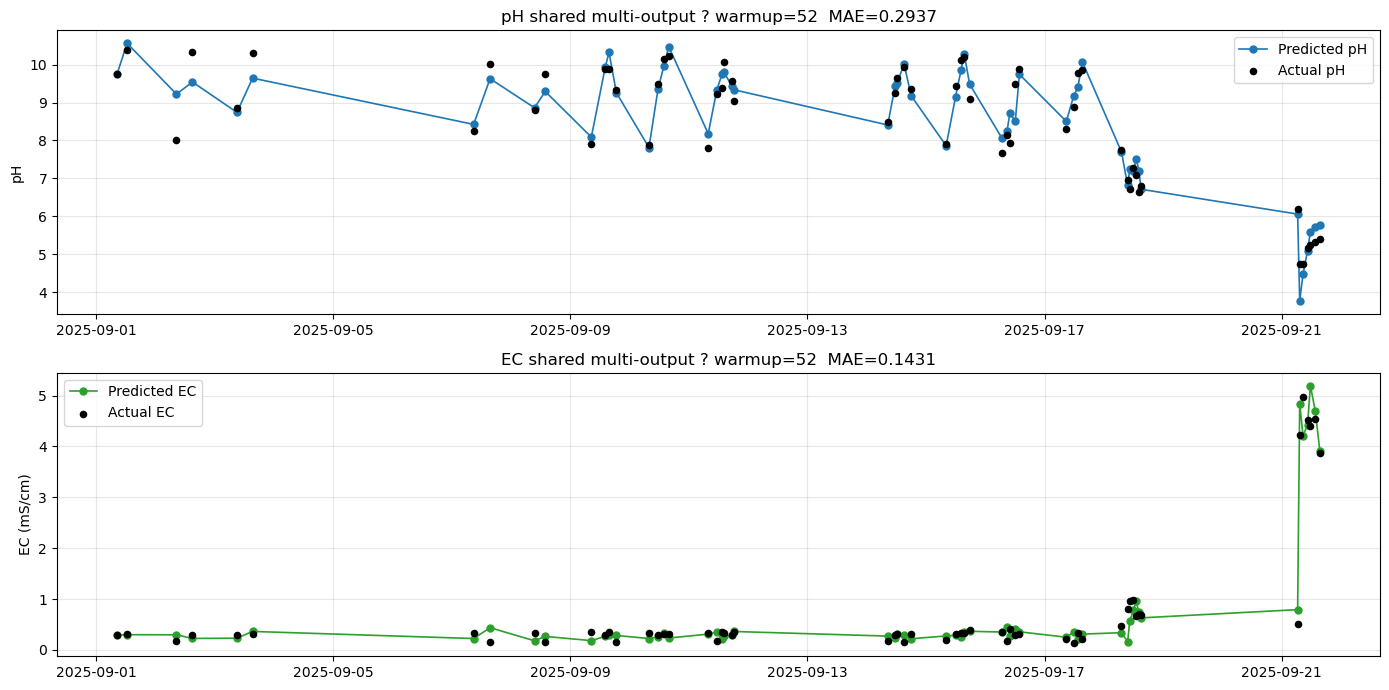

In [8]:

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=False)

axes[0].plot(res_ph.index, res_ph['ph_pred'], 'o-', color='tab:blue', ms=5, lw=1.2, label='Predicted pH')
axes[0].scatter(ev_ph.index, ev_ph['ph_true'], color='black', s=20, zorder=5, label='Actual pH')
axes[0].set_ylabel('pH')
axes[0].set_title(f'pH shared multi-output ? warmup={SHARED_WARMUP}  MAE={m_ph["ph_mae"]:.4f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(res_ec.index, res_ec['ec_pred'], 'o-', color='tab:green', ms=5, lw=1.2, label='Predicted EC')
axes[1].scatter(ev_ec.index, ev_ec['ec_true'], color='black', s=20, zorder=5, label='Actual EC')
axes[1].set_ylabel('EC (mS/cm)')
axes[1].set_title(f'EC shared multi-output ? warmup={SHARED_WARMUP}  MAE={m_ec["ec_mae"]:.4f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Global XGBoost: history importance = 0.067 (6.7%)
pH XGBoost: history importance = 0.069 (6.9%)
EC XGBoost: history importance = 0.054 (5.4%)

Top global XGBoost features from all trees:


,global_xgb_gain_importance,global_xgb_total_gain,global_xgb_split_count
ph0,0.172528,406.278260,323
photo_temp_interaction,0.141309,332.761313,230
ET0_per_hour,0.083958,197.708349,186
soil_temp_mean,0.081672,192.326054,175
transpiration_pull,0.060073,141.462736,251
ec0,0.047887,112.765904,252
temp_x_canopy,0.036502,85.957894,284
hour_sin_b,0.032102,75.596548,189
irr_to_et0,0.029285,68.962889,214
hist_hrs_since_fert,0.027306,64.300634,167



Top pH XGBoost features:


,ph_xgb_gain_importance,ph_xgb_total_gain,ph_xgb_split_count
ph0,0.197366,399.056582,229
photo_temp_interaction,0.154497,312.380209,121
ET0_per_hour,0.096382,194.876189,132
soil_temp_mean,0.091160,184.318753,99
transpiration_pull,0.063204,127.792637,128
ec0,0.039736,80.341975,155
temp_x_canopy,0.036016,72.820954,170
hour_sin_b,0.033167,67.061382,91
hist_hrs_since_fert,0.029254,59.149993,100
irr_to_et0,0.028498,57.621284,118



Top EC XGBoost features:


,ec_xgb_gain_importance,ec_xgb_total_gain,ec_xgb_split_count
ec0_x_p48_salt,0.097778,32.554028,107
ec0,0.097387,32.423929,97
prev_ec_slope,0.091501,30.464165,127
ec_log_anchor,0.064657,21.526717,46
photo_temp_interaction,0.061216,20.381103,109
log_ec_drive,0.052880,17.605695,105
transpiration_pull,0.041059,13.670099,123
temp_x_canopy,0.039458,13.136940,114
hist48_irr_prevday,0.039439,13.130755,42
irr_to_et0,0.034065,11.341604,96


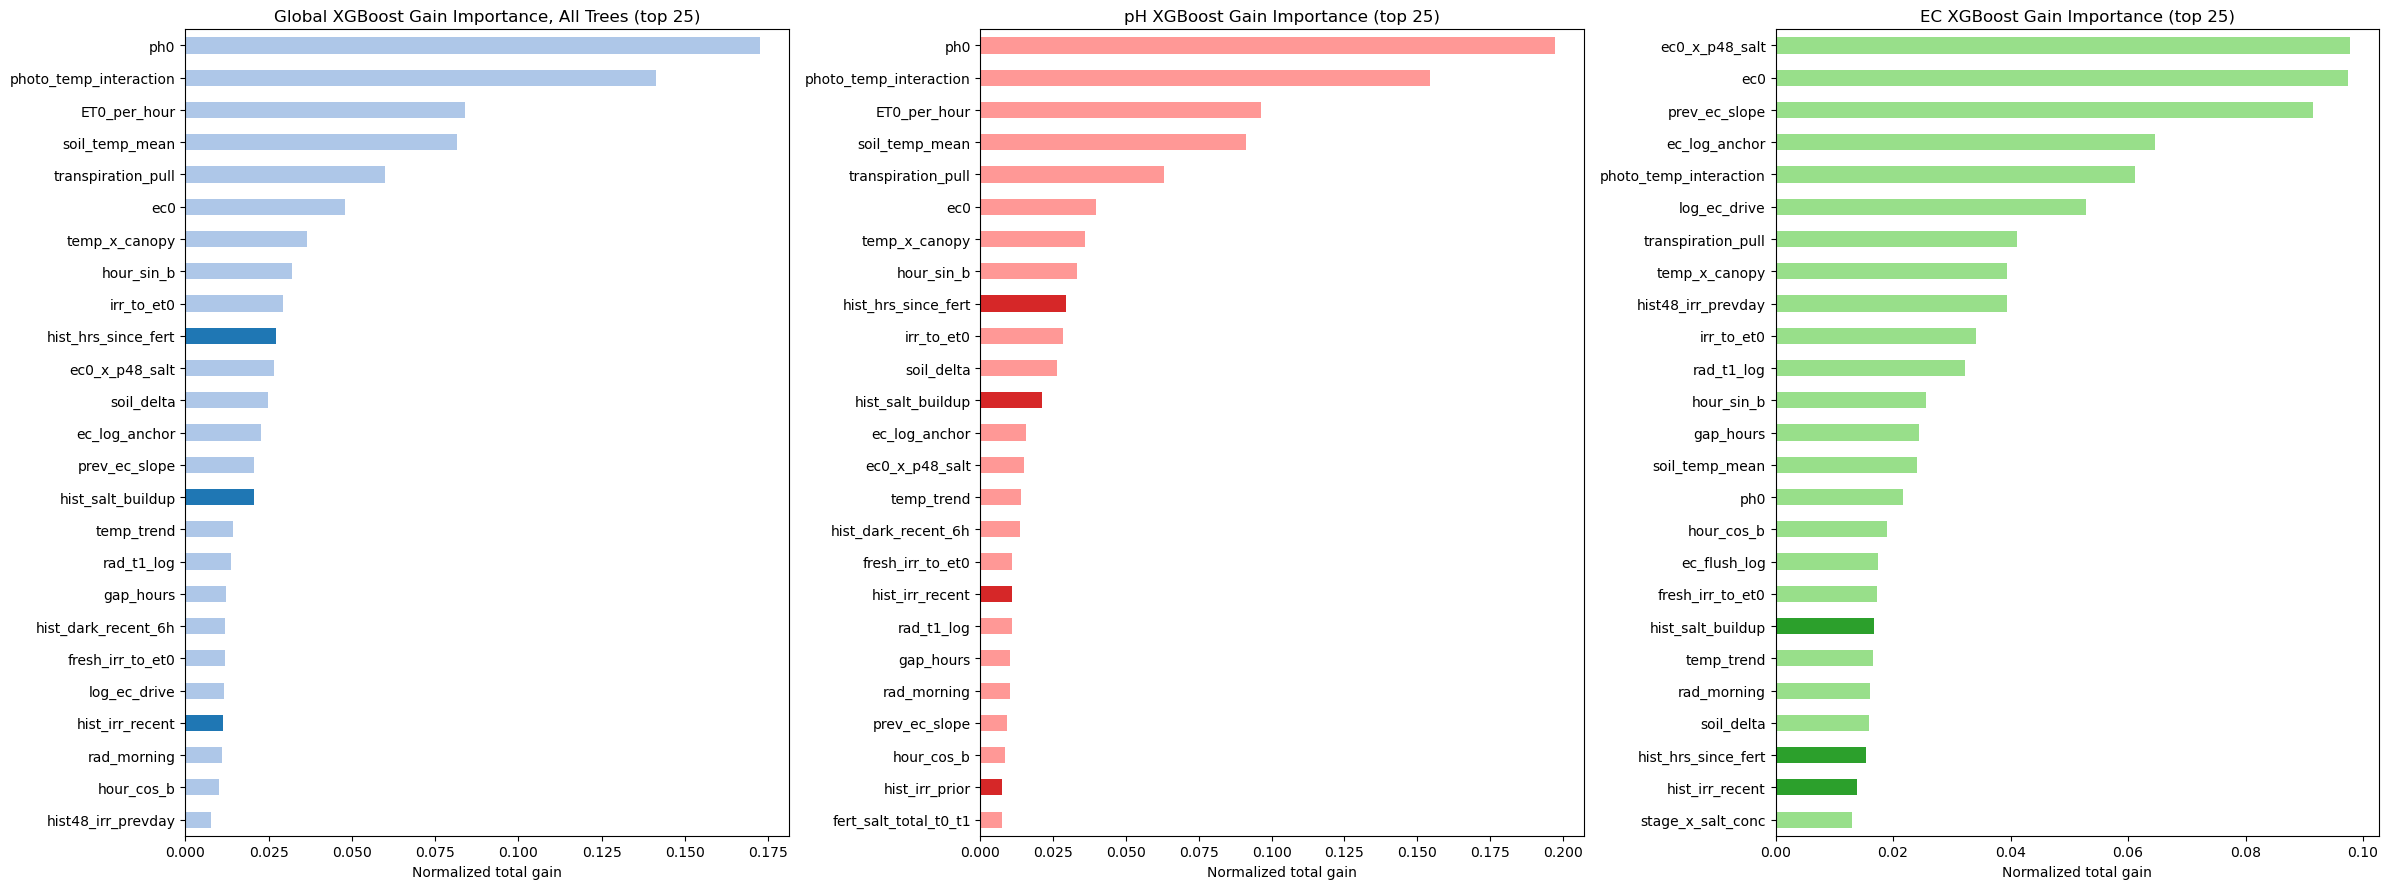

In [9]:

# ==========================================
# Target-specific XGBoost feature importance
# ==========================================
# XGBoost trains one tree per target in each boosting round:
# even tree IDs -> pH_delta, odd tree IDs -> EC_log_delta.
# This lets us calculate global total-gain importance from all trees together,
# plus separate total-gain importance for pH and EC.

def xgb_importance_by_target(shared_model, feature_cols):
    tree_df = shared_model['base'].get_booster().trees_to_dataframe()
    split_df = tree_df[tree_df['Feature'] != 'Leaf'].copy()
    split_df['target'] = np.where(split_df['Tree'] % 2 == 0, 'pH_delta', 'EC_log_delta')

    out = pd.DataFrame(index=feature_cols)
    global_gain = split_df.groupby('Feature')['Gain'].sum().reindex(feature_cols).fillna(0.0)
    global_split_count = split_df.groupby('Feature').size().reindex(feature_cols).fillna(0).astype(int)
    out['global_xgb_total_gain'] = global_gain
    out['global_xgb_gain_importance'] = global_gain / global_gain.sum() if global_gain.sum() else global_gain
    out['global_xgb_split_count'] = global_split_count

    for target_name, prefix in [('pH_delta', 'ph'), ('EC_log_delta', 'ec')]:
        g = split_df[split_df['target'] == target_name]
        total_gain = g.groupby('Feature')['Gain'].sum().reindex(feature_cols).fillna(0.0)
        split_count = g.groupby('Feature').size().reindex(feature_cols).fillna(0).astype(int)
        out[f'{prefix}_xgb_total_gain'] = total_gain
        out[f'{prefix}_xgb_gain_importance'] = total_gain / total_gain.sum() if total_gain.sum() else total_gain
        out[f'{prefix}_xgb_split_count'] = split_count

    out['mean_target_xgb_gain_importance'] = out[
        ['ph_xgb_gain_importance', 'ec_xgb_gain_importance']
    ].mean(axis=1)
    return out


xgb_target_imp = xgb_importance_by_target(shared_model, shared_feature_cols)
base_imp = xgb_target_imp['global_xgb_gain_importance'].sort_values()
ph_xgb_imp = xgb_target_imp['ph_xgb_gain_importance'].sort_values()
ec_xgb_imp = xgb_target_imp['ec_xgb_gain_importance'].sort_values()

fig, axes = plt.subplots(1, 3, figsize=(24, 9))

base_imp.tail(25).plot(
    kind='barh',
    ax=axes[0],
    color=['#1f77b4' if f in HIST_FEATS else '#aec7e8' for f in base_imp.tail(25).index],
)
axes[0].set_title('Global XGBoost Gain Importance, All Trees (top 25)')
axes[0].set_xlabel('Normalized total gain')

ph_xgb_imp.tail(25).plot(
    kind='barh',
    ax=axes[1],
    color=['#d62728' if f in HIST_FEATS else '#ff9896' for f in ph_xgb_imp.tail(25).index],
)
axes[1].set_title('pH XGBoost Gain Importance (top 25)')
axes[1].set_xlabel('Normalized total gain')

ec_xgb_imp.tail(25).plot(
    kind='barh',
    ax=axes[2],
    color=['#2ca02c' if f in HIST_FEATS else '#98df8a' for f in ec_xgb_imp.tail(25).index],
)
axes[2].set_title('EC XGBoost Gain Importance (top 25)')
axes[2].set_xlabel('Normalized total gain')

base_hist = float(base_imp[[f for f in base_imp.index if f in HIST_FEATS]].sum())
ph_hist = float(ph_xgb_imp[[f for f in ph_xgb_imp.index if f in HIST_FEATS]].sum())
ec_hist = float(ec_xgb_imp[[f for f in ec_xgb_imp.index if f in HIST_FEATS]].sum())

print(f'Global XGBoost: history importance = {base_hist:.3f} ({base_hist*100:.1f}%)')
print(f'pH XGBoost: history importance = {ph_hist:.3f} ({ph_hist*100:.1f}%)')
print(f'EC XGBoost: history importance = {ec_hist:.3f} ({ec_hist*100:.1f}%)')

print('\nTop global XGBoost features from all trees:')
display(
    xgb_target_imp
    .sort_values('global_xgb_gain_importance', ascending=False)
    [['global_xgb_gain_importance', 'global_xgb_total_gain', 'global_xgb_split_count']]
    .head(15)
)

print('\nTop pH XGBoost features:')
display(
    xgb_target_imp
    .sort_values('ph_xgb_gain_importance', ascending=False)
    [['ph_xgb_gain_importance', 'ph_xgb_total_gain', 'ph_xgb_split_count']]
    .head(15)
)

print('\nTop EC XGBoost features:')
display(
    xgb_target_imp
    .sort_values('ec_xgb_gain_importance', ascending=False)
    [['ec_xgb_gain_importance', 'ec_xgb_total_gain', 'ec_xgb_split_count']]
    .head(15)
)

plt.tight_layout()
plt.show()


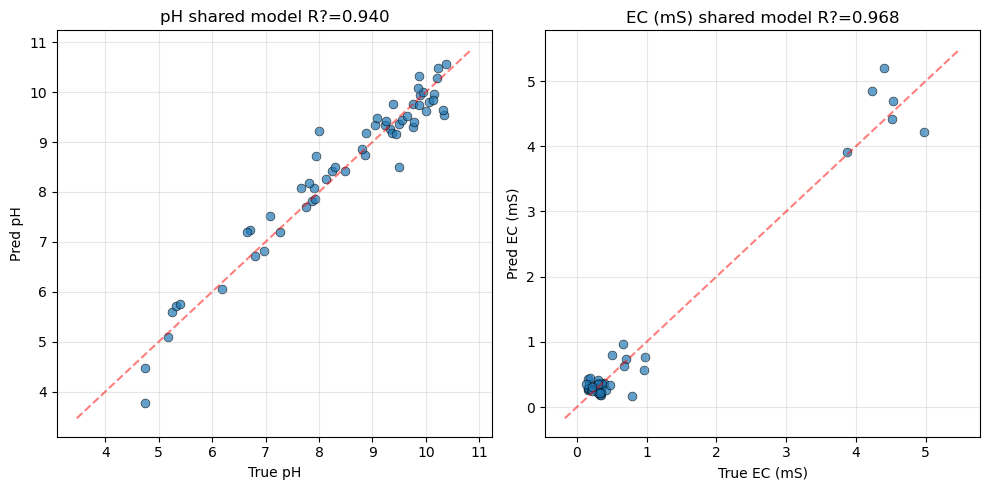

In [10]:

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, ev, name, tc, pc in [
    (axes[0], ev_ph, 'pH',      'ph_true', 'ph_pred'),
    (axes[1], ev_ec, 'EC (mS)', 'ec_true', 'ec_pred'),
]:
    t = ev[tc].values
    p = ev[pc].values
    ax.scatter(t, p, alpha=0.7, s=40, edgecolors='k', lw=0.5)
    lims = [min(t.min(), p.min()) - 0.3, max(t.max(), p.max()) + 0.3]
    ax.plot(lims, lims, 'r--', alpha=0.5)
    ax.set_xlabel(f'True {name}')
    ax.set_ylabel(f'Pred {name}')
    ax.set_title(f'{name} shared model R?={r2_score(t, p):.3f}')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


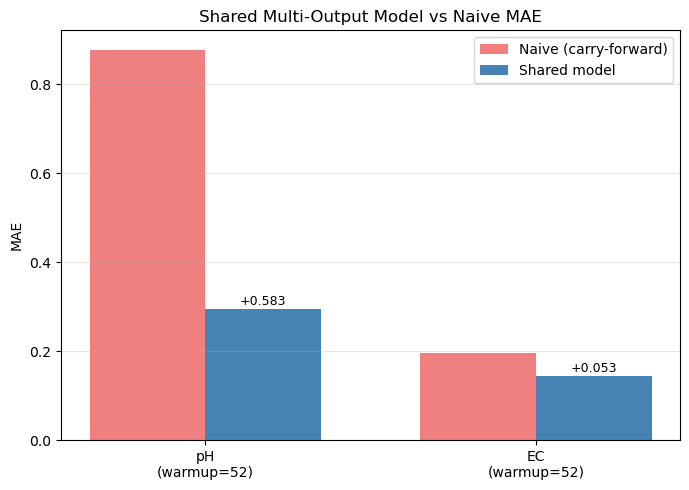

In [11]:

targets = ['pH', 'EC']
model_mae = [m_ph['ph_mae'], m_ec['ec_mae']]
naive_mae = [m_ph['ph_mae_naive'], m_ec['ec_mae_naive']]

x = np.arange(len(targets))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(x - width/2, naive_mae, width, label='Naive (carry-forward)', color='lightcoral')
ax.bar(x + width/2, model_mae, width, label='Shared model', color='steelblue')

for i, (m, n) in enumerate(zip(model_mae, naive_mae)):
    gain = n - m
    ax.text(i + width/2, m + 0.002, f'+{gain:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels([f'pH\n(warmup={SHARED_WARMUP})', f'EC\n(warmup={SHARED_WARMUP})'])
ax.set_ylabel('MAE')
ax.set_title('Shared Multi-Output Model vs Naive MAE')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


In [12]:

summary = pd.DataFrame([
    {'Target': 'pH', 'Warmup': SHARED_WARMUP, 'MAE': m_ph['ph_mae'], 'RMSE': m_ph['ph_rmse'],
     'Naive MAE': m_ph['ph_mae_naive'], 'Gain': m_ph['ph_gain_mae'], 'R2': m_ph['ph_r2'], 'N test': m_ph['n_test'],
     'Holdout MAE': ph_mae, 'Holdout R2': ph_r2},
    {'Target': 'EC', 'Warmup': SHARED_WARMUP, 'MAE': m_ec['ec_mae'], 'RMSE': m_ec['ec_rmse'],
     'Naive MAE': m_ec['ec_mae_naive'], 'Gain': m_ec['ec_gain_mae'], 'R2': m_ec['ec_r2'], 'N test': m_ec['n_test'],
     'Holdout MAE': ec_mae, 'Holdout R2': ec_r2},
]).set_index('Target')
print(summary.to_string())


        Warmup       MAE      RMSE  Naive MAE      Gain        R2  N test  Holdout MAE  Holdout R2
Target                                                                                            
pH          52  0.293736  0.390470   0.876842  0.583106  0.939732      57     0.336195    0.928420
EC          52  0.143128  0.226315   0.196077  0.052949  0.968032      57     0.185488    0.935559


In [13]:

import os
os.makedirs('exports', exist_ok=True)

EXPORT_PREFIX = 'v8_unified_augustflush_balanced_ecshift005'

ev_ph[['ph_true', 'ph_pred', 'ph_naive', 'gap_hours', 'n_train', 'specialist_active', 'specialist_type']].to_csv(f'exports/{EXPORT_PREFIX}_eval_ph.csv')
ev_ec[['ec_true', 'ec_pred', 'ec_naive', 'gap_hours', 'n_train', 'specialist_active', 'specialist_type']].to_csv(f'exports/{EXPORT_PREFIX}_eval_ec.csv')
res_ph[['ph_pred', 'gap_hours', 'n_train', 'specialist_active', 'specialist_type']].to_csv(f'exports/{EXPORT_PREFIX}_pred_ph.csv')
res_ec[['ec_pred', 'gap_hours', 'n_train', 'specialist_active', 'specialist_type']].to_csv(f'exports/{EXPORT_PREFIX}_pred_ec.csv')
hdf.to_csv(f'exports/{EXPORT_PREFIX}_holdout_detail.csv', index=False)
summary.to_csv(f'exports/{EXPORT_PREFIX}_summary.csv')

base_imp.sort_values(ascending=False).to_csv(f'exports/{EXPORT_PREFIX}_fi_shared_xgb.csv', header=['importance'])
xgb_target_imp.sort_values('global_xgb_gain_importance', ascending=False).to_csv(
    f'exports/{EXPORT_PREFIX}_fi_xgb_by_target.csv'
)

print(f'{EXPORT_PREFIX} exports done - files written to exports/')
print(f'  {EXPORT_PREFIX}_eval_ph.csv        {len(ev_ph)} rows')
print(f'  {EXPORT_PREFIX}_eval_ec.csv        {len(ev_ec)} rows')
print(f'  {EXPORT_PREFIX}_pred_ph.csv        {len(res_ph)} rows')
print(f'  {EXPORT_PREFIX}_pred_ec.csv        {len(res_ec)} rows')
print(f'  {EXPORT_PREFIX}_holdout_detail.csv {len(hdf)} rows')
print(f'  {EXPORT_PREFIX}_fi_shared_xgb.csv       {len(base_imp)} features')
print(f'  {EXPORT_PREFIX}_fi_xgb_by_target.csv    {len(xgb_target_imp)} features')


v8_unified_augustflush_balanced_ecshift005 exports done - files written to exports/
  v8_unified_augustflush_balanced_ecshift005_eval_ph.csv        57 rows
  v8_unified_augustflush_balanced_ecshift005_eval_ec.csv        57 rows
  v8_unified_augustflush_balanced_ecshift005_pred_ph.csv        57 rows
  v8_unified_augustflush_balanced_ecshift005_pred_ec.csv        57 rows
  v8_unified_augustflush_balanced_ecshift005_holdout_detail.csv 40 rows
  v8_unified_augustflush_balanced_ecshift005_fi_shared_xgb.csv       39 features
  v8_unified_augustflush_balanced_ecshift005_fi_xgb_by_target.csv    39 features


## EC Warmup30 Stress Check

The cells below rerun the same strict unified model from warmup 30. Nothing changes except the evaluation start:
- same `shared_feature_cols`
- same XGBoost params
- same Huber params
- same Huber gate/blend
- same pH delta and EC log-delta target setup


In [14]:

def run_shared_walkforward_with_warmup(warmup):
    train_df = pd.DataFrame(_build_shared_rows(warmup)).set_index('timestamp').sort_index()
    model = _fit_shared_model(train_df)

    rows = []
    anchor = sensor_idx[warmup]
    retrain_count = 0

    for k in range(warmup, len(sensor_idx)):
        cur = sensor_idx[k]
        feats = _augment_shared_features(get_features_v6(master_df, anchor, cur))
        if feats['gap_hours'] <= 0:
            raw, specialist_type = np.array([0.0, 0.0]), 'base'
        else:
            raw, specialist_type = _predict_shared_raw_and_type(model, feats)

        ph_pred = feats['ph0'] + raw[0]
        ec_pred = max(0.0, (feats['ec0'] + EC_TARGET_SHIFT) * np.exp(raw[1]) - EC_TARGET_SHIFT)

        rows.append({
            'timestamp': cur,
            'gap_hours': feats['gap_hours'],
            'ph_true': float(master_df.loc[cur, 'ph']),
            'ph_pred': ph_pred,
            'ph_naive': feats['ph0'],
            'ec_true': float(master_df.loc[cur, 'ec_ms']),
            'ec_pred': ec_pred,
            'ec_naive': feats['ec0'],
            'n_train': len(train_df),
            'specialist_active': specialist_type != 'base',
            'specialist_type': specialist_type,
        })

        if k > warmup:
            new_rows = [_make_shared_row(k - 1, k)]
            for j, _, back, _ in _selected_shared_skip_pairs(k):
                new_rows.append(_make_shared_row(j, k, sensor_idx[k] + pd.Timedelta(microseconds=back)))
            train_df = pd.concat([train_df, pd.DataFrame(new_rows).set_index('timestamp')]).sort_index()
            model = _fit_shared_model(train_df)
            retrain_count += 1

        anchor = cur

    ev = pd.DataFrame(rows).set_index('timestamp')
    return model, ev, retrain_count


STRESS_WARMUP_EC = 30
stress_model, stress_ev, stress_retrains = run_shared_walkforward_with_warmup(STRESS_WARMUP_EC)
ev_ec_stress = stress_ev[['ec_true', 'ec_pred', 'ec_naive', 'gap_hours', 'n_train', 'specialist_active', 'specialist_type']].copy()
res_ec_stress = stress_ev[['ec_pred', 'gap_hours', 'n_train', 'specialist_active', 'specialist_type']].copy()

m_ec_stress = {
    'warmup': STRESS_WARMUP_EC,
    'target': 'ec',
    'ec_mae': float(mean_absolute_error(stress_ev['ec_true'], stress_ev['ec_pred'])),
    'ec_rmse': _rmse(stress_ev['ec_true'], stress_ev['ec_pred']),
    'ec_mae_naive': float(mean_absolute_error(stress_ev['ec_true'], stress_ev['ec_naive'])),
    'ec_gain_mae': float(mean_absolute_error(stress_ev['ec_true'], stress_ev['ec_naive']) - mean_absolute_error(stress_ev['ec_true'], stress_ev['ec_pred'])),
    'ec_r2': float(r2_score(stress_ev['ec_true'], stress_ev['ec_pred'])),
    'n_test': int(len(stress_ev)),
}

print(f'EC unified compact35 strictblend95 stress check (warmup={STRESS_WARMUP_EC}): '
      f'MAE={m_ec_stress["ec_mae"]:.4f}  naive={m_ec_stress["ec_mae_naive"]:.4f}  '
      f'gain={m_ec_stress["ec_gain_mae"]:.4f}  R2={m_ec_stress["ec_r2"]:.4f}')
print(f'Stress retrains: {stress_retrains}')
print(f'Stress specialist predictions: {int((stress_ev["specialist_type"] == "huber").sum())}')

sep21_stress = ev_ec_stress.loc[ev_ec_stress.index.astype(str).str.startswith('2025-09-21')]
print('\nSep 21 EC stress detail:')
display(sep21_stress[['ec_true', 'ec_pred', 'ec_naive', 'gap_hours', 'specialist_type']])


EC unified compact35 strictblend95 stress check (warmup=30): MAE=0.1775  naive=0.2467  gain=0.0693  R2=0.9379
Stress retrains: 78
Stress specialist predictions: 2

Sep 21 EC stress detail:


,ec_true,ec_pred,ec_naive,gap_hours,specialist_type
timestamp,,,,,
2025-09-21 06:30:00,0.501,0.791636,0.680,63.333333,base
2025-09-21 07:20:00,4.230,4.843689,0.501,0.833333,huber
2025-09-21 08:40:00,4.970,4.213222,4.230,1.333333,base
2025-09-21 10:30:00,4.520,4.424467,4.970,1.833333,base
2025-09-21 11:40:00,4.400,5.194191,4.520,1.166667,base
2025-09-21 13:40:00,4.530,4.690492,4.400,2.000000,base
2025-09-21 15:30:00,3.870,3.904044,4.530,1.833333,base


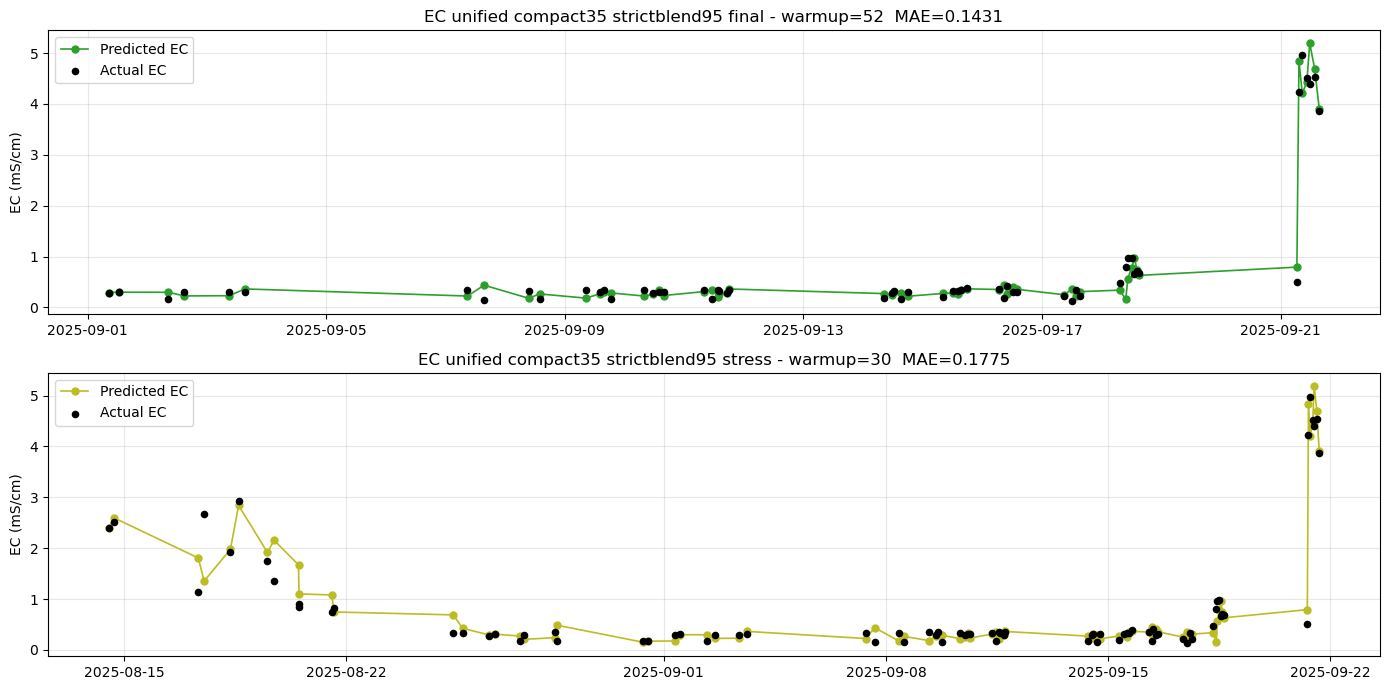

In [15]:

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=False)

axes[0].plot(res_ec.index, res_ec['ec_pred'], 'o-', color='tab:green', ms=5, lw=1.2, label='Predicted EC')
axes[0].scatter(ev_ec.index, ev_ec['ec_true'], color='black', s=20, zorder=5, label='Actual EC')
axes[0].set_ylabel('EC (mS/cm)')
axes[0].set_title(f'EC unified compact35 strictblend95 final - warmup={SHARED_WARMUP}  MAE={m_ec["ec_mae"]:.4f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(res_ec_stress.index, res_ec_stress['ec_pred'], 'o-', color='tab:olive', ms=5, lw=1.2, label='Predicted EC')
axes[1].scatter(ev_ec_stress.index, ev_ec_stress['ec_true'], color='black', s=20, zorder=5, label='Actual EC')
axes[1].set_ylabel('EC (mS/cm)')
axes[1].set_title(f'EC unified compact35 strictblend95 stress - warmup={STRESS_WARMUP_EC}  MAE={m_ec_stress["ec_mae"]:.4f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [16]:

strict_unified_summary = summary.copy()
strict_unified_stress_row = pd.DataFrame([
    {
        'Target': 'EC stress',
        'Warmup': STRESS_WARMUP_EC,
        'MAE': m_ec_stress['ec_mae'],
        'RMSE': m_ec_stress['ec_rmse'],
        'Naive MAE': m_ec_stress['ec_mae_naive'],
        'Gain': m_ec_stress['ec_gain_mae'],
        'R2': m_ec_stress['ec_r2'],
        'N test': m_ec_stress['n_test'],
        'Holdout MAE': np.nan,
        'Holdout R2': np.nan,
    }
]).set_index('Target')

strict_unified_summary = pd.concat([strict_unified_summary, strict_unified_stress_row])
print(strict_unified_summary.to_string())


           Warmup       MAE      RMSE  Naive MAE      Gain        R2  N test  Holdout MAE  Holdout R2
Target                                                                                               
pH             52  0.293736  0.390470   0.876842  0.583106  0.939732      57     0.336195    0.928420
EC             52  0.143128  0.226315   0.196077  0.052949  0.968032      57     0.185488    0.935559
EC stress      30  0.177463  0.294503   0.246735  0.069272  0.937899      79          NaN         NaN


In [17]:

EXPORT_PREFIX = 'v8_unified_augustflush_balanced_ecshift005'
ev_ec_stress.to_csv(f'exports/{EXPORT_PREFIX}_eval_ec_warmup30.csv')
res_ec_stress.to_csv(f'exports/{EXPORT_PREFIX}_pred_ec_warmup30.csv')
strict_unified_summary.to_csv(f'exports/{EXPORT_PREFIX}_summary_with_ec_warmup30.csv')

pd.Series(shared_feature_cols, name='feature').to_csv(f'exports/{EXPORT_PREFIX}_features.csv', index=False)

print(f'{EXPORT_PREFIX} EC warmup30 stress exports done')
print(f'  {EXPORT_PREFIX}_eval_ec_warmup30.csv {len(ev_ec_stress)} rows')
print(f'  {EXPORT_PREFIX}_summary_with_ec_warmup30.csv')


v8_unified_augustflush_balanced_ecshift005 EC warmup30 stress exports done
  v8_unified_augustflush_balanced_ecshift005_eval_ec_warmup30.csv 79 rows
  v8_unified_augustflush_balanced_ecshift005_summary_with_ec_warmup30.csv


## Regime-Balanced Evaluation

Global metrics are not enough for this dataset because most EC samples are low and stable. These cells report each target by regime and compute balanced MAE:

- EC regimes: low EC, high EC, very high EC, EC shock/jump.
- pH regimes: mid-range pH, acidic pH, alkaline pH, pH jump.
- Balanced MAE: average MAE across important regimes, so the common stable regime cannot dominate the result.


In [18]:

def _safe_r2(y_true, y_pred):
    y_true = pd.Series(y_true)
    if len(y_true) < 2 or y_true.nunique() <= 1:
        return np.nan
    return float(r2_score(y_true, y_pred))


def _metric_row(df, target, regime_name):
    if len(df) == 0:
        return {
            'regime': regime_name,
            'n': 0,
            'mae': np.nan,
            'rmse': np.nan,
            'r2': np.nan,
            'naive_mae': np.nan,
            'gain_vs_naive': np.nan,
            'mean_true': np.nan,
            'max_true': np.nan,
        }
    y = df[f'{target}_true']
    pred = df[f'{target}_pred']
    naive = df[f'{target}_naive']
    mae = float(mean_absolute_error(y, pred))
    naive_mae = float(mean_absolute_error(y, naive))
    return {
        'regime': regime_name,
        'n': int(len(df)),
        'mae': mae,
        'rmse': _rmse(y, pred),
        'r2': _safe_r2(y, pred),
        'naive_mae': naive_mae,
        'gain_vs_naive': naive_mae - mae,
        'mean_true': float(y.mean()),
        'max_true': float(y.max()),
    }


def ec_regime_metrics(ev, label):
    df = ev.copy()
    df['abs_delta_ec'] = (df['ec_true'] - df['ec_naive']).abs()
    regimes = [
        ('all', df),
        ('low_ec_true_lt_1', df[df['ec_true'] < 1.0]),
        ('high_ec_true_ge_1', df[df['ec_true'] >= 1.0]),
        ('very_high_ec_true_ge_2', df[df['ec_true'] >= 2.0]),
        ('shock_abs_delta_ge_0.5', df[df['abs_delta_ec'] >= 0.5]),
        ('shock_abs_delta_ge_1.0', df[df['abs_delta_ec'] >= 1.0]),
    ]
    out = pd.DataFrame([_metric_row(part, 'ec', name) for name, part in regimes])
    out.insert(0, 'evaluation', label)
    balanced_parts = out[out['regime'].isin(['low_ec_true_lt_1', 'high_ec_true_ge_1', 'shock_abs_delta_ge_0.5'])]
    balanced_mae = float(balanced_parts['mae'].dropna().mean())
    return out, balanced_mae


def ph_regime_metrics(ev, label):
    df = ev.copy()
    df['abs_delta_ph'] = (df['ph_true'] - df['ph_naive']).abs()
    regimes = [
        ('all', df),
        ('mid_ph_6.5_to_9.5', df[(df['ph_true'] > 6.5) & (df['ph_true'] < 9.5)]),
        ('acidic_ph_le_6.5', df[df['ph_true'] <= 6.5]),
        ('alkaline_ph_ge_9.5', df[df['ph_true'] >= 9.5]),
        ('jump_abs_delta_ge_0.75', df[df['abs_delta_ph'] >= 0.75]),
        ('jump_abs_delta_ge_1.0', df[df['abs_delta_ph'] >= 1.0]),
    ]
    out = pd.DataFrame([_metric_row(part, 'ph', name) for name, part in regimes])
    out.insert(0, 'evaluation', label)
    balanced_parts = out[out['regime'].isin([
        'mid_ph_6.5_to_9.5',
        'acidic_ph_le_6.5',
        'alkaline_ph_ge_9.5',
        'jump_abs_delta_ge_0.75',
    ])]
    balanced_mae = float(balanced_parts['mae'].dropna().mean())
    return out, balanced_mae


def _holdout_eval_frame(hdf):
    return hdf.copy()


ec_regime_w52, ec_balanced_w52 = ec_regime_metrics(ev_ec, 'EC warmup52')
ec_regime_w30, ec_balanced_w30 = ec_regime_metrics(ev_ec_stress, 'EC warmup30')
ec_regime_holdout, ec_balanced_holdout = ec_regime_metrics(_holdout_eval_frame(hdf), 'EC holdout')

ph_regime_w52, ph_balanced_w52 = ph_regime_metrics(ev_ph, 'pH warmup52')
ph_regime_holdout, ph_balanced_holdout = ph_regime_metrics(_holdout_eval_frame(hdf), 'pH holdout')

balanced_summary = pd.DataFrame([
    {'target': 'EC', 'evaluation': 'warmup52', 'global_mae': m_ec['ec_mae'], 'balanced_mae': ec_balanced_w52},
    {'target': 'EC', 'evaluation': 'warmup30', 'global_mae': m_ec_stress['ec_mae'], 'balanced_mae': ec_balanced_w30},
    {'target': 'EC', 'evaluation': 'holdout', 'global_mae': float(mean_absolute_error(hdf['ec_true'], hdf['ec_pred'])), 'balanced_mae': ec_balanced_holdout},
    {'target': 'pH', 'evaluation': 'warmup52', 'global_mae': m_ph['ph_mae'], 'balanced_mae': ph_balanced_w52},
    {'target': 'pH', 'evaluation': 'holdout', 'global_mae': float(mean_absolute_error(hdf['ph_true'], hdf['ph_pred'])), 'balanced_mae': ph_balanced_holdout},
])
balanced_summary['balanced_minus_global'] = balanced_summary['balanced_mae'] - balanced_summary['global_mae']

print('Balanced MAE summary')
display(balanced_summary)

print('\nEC regime metrics - warmup52')
display(ec_regime_w52)
print('\nEC regime metrics - warmup30')
display(ec_regime_w30)
print('\nEC regime metrics - holdout')
display(ec_regime_holdout)

print('\npH regime metrics - warmup52')
display(ph_regime_w52)
print('\npH regime metrics - holdout')
display(ph_regime_holdout)


Balanced MAE summary


,target,evaluation,global_mae,balanced_mae,balanced_minus_global
0,EC,warmup52,0.143128,0.329709,0.186581
1,EC,warmup30,0.177463,0.326952,0.149490
2,EC,holdout,0.185488,0.427350,0.241862
3,pH,warmup52,0.293736,0.323614,0.029878
4,pH,holdout,0.336195,0.421015,0.084820



EC regime metrics - warmup52


,evaluation,regime,n,mae,rmse,r2,naive_mae,gain_vs_naive,mean_true,max_true
0,EC warmup52,all,57,0.143128,0.226315,0.968032,0.196077,0.052949,0.779260,4.97
1,EC warmup52,low_ec_true_lt_1,51,0.111834,0.159862,0.265517,0.104851,-0.006983,0.350937,0.98
2,EC warmup52,high_ec_true_ge_1,6,0.409121,0.518991,-1.435368,0.971500,0.562379,4.420000,4.97
3,EC warmup52,very_high_ec_true_ge_2,6,0.409121,0.518991,-1.435368,0.971500,0.562379,4.420000,4.97
4,EC warmup52,shock_abs_delta_ge_0.5,3,0.468171,0.562876,-0.510949,1.709667,1.241496,4.356667,4.97
5,EC warmup52,shock_abs_delta_ge_1.0,1,0.613689,0.613689,NaN,3.729000,3.115311,4.230000,4.23



EC regime metrics - warmup30


...

,evaluation,regime,n,mae,rmse,r2,naive_mae,gain_vs_naive,mean_true,max_true
0,EC holdout,all,40,0.185488,0.339139,0.935559,0.556922,0.371434,0.999682,4.970
1,EC holdout,low_ec_true_lt_1,32,0.090077,0.147967,0.411552,0.137309,0.047233,0.382041,0.968
2,EC holdout,high_ec_true_ge_1,8,0.567135,0.698210,0.574482,2.235375,1.668240,3.470250,4.970
3,EC holdout,very_high_ec_true_ge_2,7,0.609561,0.739401,0.407677,2.442286,1.832724,3.690000,4.970
4,EC holdout,shock_abs_delta_ge_0.5,8,0.624839,0.730591,0.776238,2.374500,1.749661,3.094375,4.970
5,EC holdout,shock_abs_delta_ge_1.0,5,0.746873,0.858481,-1.195933,3.375200,2.628327,4.212000,4.970



pH regime metrics - warmup52


,evaluation,regime,n,mae,rmse,r2,naive_mae,gain_vs_naive,mean_true,max_true
0,pH warmup52,all,57,0.293736,0.390470,0.939732,0.876842,0.583106,8.488772,10.38
1,pH warmup52,mid_ph_6.5_to_9.5,29,0.273257,0.372793,0.816115,1.043448,0.770191,8.214828,9.45
2,pH warmup52,acidic_ph_le_6.5,7,0.367296,0.457951,-0.035472,0.385714,0.018418,5.262857,6.19
3,pH warmup52,alkaline_ph_ge_9.5,21,0.297497,0.389892,-1.170503,0.810476,0.512979,9.942381,10.38
4,pH warmup52,jump_abs_delta_ge_0.75,25,0.356407,0.482419,0.844979,1.563200,1.206793,8.680400,10.34
5,pH warmup52,jump_abs_delta_ge_1.0,21,0.368935,0.507505,0.830144,1.697619,1.328684,8.630476,10.34



pH regime metrics - holdout


,evaluation,regime,n,mae,rmse,r2,naive_mae,gain_vs_naive,mean_true,max_true
0,pH holdout,all,40,0.336195,0.411901,0.928420,0.899500,0.563305,8.496500,10.38
1,pH holdout,mid_ph_6.5_to_9.5,20,0.367871,0.417763,0.758399,0.927000,0.559129,8.045000,9.39
2,pH holdout,acidic_ph_le_6.5,4,0.714651,0.766817,-8.022862,1.007500,0.292849,5.182500,5.40
3,pH holdout,alkaline_ph_ge_9.5,16,0.201987,0.242890,0.102812,0.838125,0.636138,9.889375,10.38
4,pH holdout,jump_abs_delta_ge_0.75,24,0.399552,0.470595,0.926368,1.282083,0.882531,8.376250,10.22
5,pH holdout,jump_abs_delta_ge_1.0,17,0.362459,0.409545,0.913501,1.460588,1.098129,8.535882,10.06


In [19]:

def _window_metrics(ev, target, start, end, label):
    part = ev[(ev.index >= pd.Timestamp(start)) & (ev.index < pd.Timestamp(end))].copy()
    return _metric_row(part, target, label)


ec_case_studies = pd.DataFrame([
    _window_metrics(ev_ec_stress, 'ec', '2025-08-14', '2025-08-23', 'EC warmup30 Aug 14-22'),
    _window_metrics(ev_ec_stress, 'ec', '2025-09-21', '2025-09-22', 'EC warmup30 Sep 21'),
    _window_metrics(ev_ec, 'ec', '2025-09-21', '2025-09-22', 'EC warmup52 Sep 21'),
])

ph_case_studies = pd.DataFrame([
    _window_metrics(ev_ph, 'ph', '2025-09-18', '2025-09-22', 'pH Sep 18-21 transition'),
    _window_metrics(ev_ph, 'ph', '2025-09-21', '2025-09-22', 'pH Sep 21'),
])

print('Time-window case studies')
display(ec_case_studies)
display(ph_case_studies)


Time-window case studies


,regime,n,mae,rmse,r2,naive_mae,gain_vs_naive,mean_true,max_true
0,EC warmup30 Aug 14-22,12,0.383867,0.551400,0.488468,0.588985,0.205118,1.668818,2.93
1,EC warmup30 Sep 21,7,0.392195,0.492889,0.877020,0.858286,0.466091,3.860143,4.97
2,EC warmup52 Sep 21,7,0.392195,0.492889,0.877020,0.858286,0.466091,3.860143,4.97


,regime,n,mae,rmse,r2,naive_mae,gain_vs_naive,mean_true,max_true
0,pH Sep 18-21 transition,14,0.319705,0.404436,0.827781,0.512143,0.192438,6.148571,7.76
1,pH Sep 21,7,0.367296,0.457951,-0.035472,0.385714,0.018418,5.262857,6.19


In [20]:

EXPORT_PREFIX = 'v8_unified_augustflush_balanced_ecshift005'

ec_regime_w52.to_csv(f'exports/{EXPORT_PREFIX}_ec_regime_warmup52.csv', index=False)
ec_regime_w30.to_csv(f'exports/{EXPORT_PREFIX}_ec_regime_warmup30.csv', index=False)
ec_regime_holdout.to_csv(f'exports/{EXPORT_PREFIX}_ec_regime_holdout.csv', index=False)
ph_regime_w52.to_csv(f'exports/{EXPORT_PREFIX}_ph_regime_warmup52.csv', index=False)
ph_regime_holdout.to_csv(f'exports/{EXPORT_PREFIX}_ph_regime_holdout.csv', index=False)
balanced_summary.to_csv(f'exports/{EXPORT_PREFIX}_balanced_summary.csv', index=False)
ec_case_studies.to_csv(f'exports/{EXPORT_PREFIX}_ec_case_studies.csv', index=False)
ph_case_studies.to_csv(f'exports/{EXPORT_PREFIX}_ph_case_studies.csv', index=False)

print(f'{EXPORT_PREFIX} regime-balanced exports done')
print(f'  {EXPORT_PREFIX}_balanced_summary.csv')
print(f'  {EXPORT_PREFIX}_ec_regime_warmup30.csv')
print(f'  {EXPORT_PREFIX}_ph_regime_warmup52.csv')


v8_unified_augustflush_balanced_ecshift005 regime-balanced exports done
  v8_unified_augustflush_balanced_ecshift005_balanced_summary.csv
  v8_unified_augustflush_balanced_ecshift005_ec_regime_warmup30.csv
  v8_unified_augustflush_balanced_ecshift005_ph_regime_warmup52.csv
